# Machine LearningAfter Bond Specific orthogonal TB

In [18]:
import pickle
import os
import glob
import numpy as np
import pdb
import pandas as pd
import copy
from importlib.machinery import SourceFileLoader
from tqdm.notebook import tqdm_notebook
import re

import matplotlib.pyplot as plt
plt.style.use('seaborn')
plt.rc('figure', figsize=(15,10))
plt.rc('legend',fontsize=24)
plt.rc('axes',labelsize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

In [4]:
from BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
#StructSummaryParser = SourceFileLoader(
#    'StructSummaryParser',
#    'BopFoxFeaturizer/brief_summary_parser.py'
#).load_module().StructSummaryParser()
from BopFoxFeaturizer.FeatureConcatenate import stackdata
#stackdata = SourceFileLoader(
#    'stackdata',
#    'BopFoxFeaturizer/FeatureConcatenate.py'
#).load_module().stackdata

In [52]:
# Original DFT Data
#briefsummary_files = pd.Series(glob.glob('**/briefsummary*.dat',recursive=True))
BS = StructSummaryParser().BriefSummary

# the moments I calculated in some other ocasion - NSC canonical tight binding model
BondSpecific = pd.read_pickle('NSC_CRCOW_CANONICAL_TABLECUTOFF.pkl')

BondSpecific.drop(columns=['NSC_U_bond_atom_list'], inplace=True)
# Atomic Averages:

BondSpecific.dropna(how='any',inplace=True)

M = BondSpecific['NSC_moments'].map(lambda M: np.array(M).mean(axis=0))
S = BondSpecific['NSC_SIGMA'].map(lambda M: np.array(M).mean(axis=0))
Binf=BondSpecific['NSC_Binf'].map(lambda s: [float(si) for si in s]).map(np.mean)
Ainf=BondSpecific['NSC_Ainf'].map(lambda s: [float(si) for si in s]).map(np.mean)
AN = BondSpecific['NSC_an'].map(lambda M: np.array(M).mean(axis=0))
BN = BondSpecific['NSC_bn'].map(lambda M: np.array(M).mean(axis=0))
BOP_atom_average = pd.concat([M, S, AN, BN, Ainf, Binf], axis=1)
# Feature Transformation to concatenation
BOP, names = stackdata(BOP_atom_average, BOP_atom_average.columns.values)
BOP = pd.DataFrame(data=BOP, columns=names, index = BOP_atom_average.index)
BOP['NSC_U_bind'] = BondSpecific['NSC_U_bind'].map(float)

del M, S, Binf, Ainf, AN, BN, BondSpecific, BOP_atom_average # now I donnt need any more individual columns

In [7]:
columns_bn = BOP.columns[BOP.columns.str.contains('bn')]

In [8]:
columns_an = BOP.columns[BOP.columns.str.contains('an')]

In [9]:
BOP

,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,NSC_moments_9,...,NSC_bn_14,NSC_bn_15,NSC_bn_16,NSC_bn_17,NSC_bn_18,NSC_bn_19,NSC_bn_20,NSC_Ainf_0,NSC_Binf_0,NSC_U_bind
index,,,,,,,,,,,,,,,,,,,,,
Co_pv6W_sv6.C14-BBA.FM,0.0,2.484897,-0.871504,12.534150,-9.601060,84.913483,-104.517300,707.065333,-1228.069000,6907.887333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.363878,1.762021,0.0
Co_pv6W_sv6.C14-BBA.NM,0.0,2.484928,-0.871516,12.534720,-9.601363,84.921383,-104.522967,707.166667,-1228.171333,6909.200000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.363818,1.762077,0.0
Cr_pv6W_sv2.D0_19-A3B.FM,0.0,1.843195,-0.438406,6.392680,-3.233468,28.662000,-20.922425,149.912000,-133.946500,867.585750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.105636,1.405171,0.0
Cr_pv6W_sv2.D0_19-A3B.NM,0.0,1.839238,-0.438267,6.364365,-3.228548,28.468550,-20.870725,148.544875,-133.505250,857.541750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.106369,1.403395,0.0
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,0.0,1.867517,-0.566954,6.426053,-3.920141,27.921180,-24.364141,138.652467,-152.110787,752.128067,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.164399,1.339743,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,0.0,1.740168,-0.535085,5.295072,-3.241148,20.335187,-17.433967,90.660387,-93.847440,449.389200,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.121055,1.322413,0.0
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,0.0,1.740205,-0.535039,5.295173,-3.240733,20.335607,-17.429680,90.663653,-93.807627,449.422533,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.120961,1.322456,0.0
Co_pv13W_sv16.chi-ABAB.NM,0.0,1.713159,-0.139743,5.435895,-1.151000,20.963417,-7.770727,90.341090,-49.511699,419.921766,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0


# Some Machine Learning

In [19]:
from seaborn import heatmap
from sklearn.kernel_ridge import KernelRidge
import matplotlib.pyplot as plt
plt.style.use('seaborn')
plt.rc('figure', figsize=(20,10))
plt.rc('legend',fontsize=20)
plt.rc('axes',labelsize=36)
plt.rc('xtick',labelsize=28)
plt.rc('ytick',labelsize=28)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from math import sqrt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import QuantileTransformer
from sklearn.pipeline import Pipeline
import sklearn

# Targets


In [21]:
# groundstates = ground_state_energies = {'Re_pv':-12.44533, 'Ni_pv':-5.726500, 'Al':-3.745590, 'Co':-7.107694, 'W_pv':-12.960454,'':0}
from BopFoxFeaturizer.Featurizer import Featurizer
featurizer = Featurizer(BS)

In [22]:
groundstates = featurizer.get_ground_states_energies()

In [23]:
BS['EF'] = featurizer.get_formation_energy(groundstates)
BS = BS.dropna()

In [24]:
BS

,,B,E0,V,deltak,encut,fit,ncrash,nelem,xc,B0,V0,atom_A,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,EF
index,,,,,,,,,,,,,,,,,,,,
Co_pv6W_sv6.C14-BBA.FM,bulk C14-BBA.FM,293.907391 GPa,-10.000427,13.175678 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,293.907391,13.175678,Co_pv,W_sv,,6,6,0,12.0,-0.038167
Co_pv6W_sv6.C14-BBA.NM,bulk C14-BBA,293.949578 GPa,-10.000427,13.175679 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,293.949578,13.175679,Co_pv,W_sv,,6,6,0,12.0,-0.038167
Cr_pv6W_sv2.D0_19-A3B.FM,bulk D0_19-A3B.FM,244.993002 GPa,-10.002413,13.098145 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,244.993002,13.098145,Cr_pv,W_sv,,6,2,0,8.0,0.272512
Cr_pv6W_sv2.D0_19-A3B.NM,bulk D0_19-A3B,248.338396 GPa,-10.002452,13.093819 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,248.338396,13.093819,Cr_pv,W_sv,,6,2,0,8.0,0.272473
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,bulk sigma-CBAAC.FM,243.415325 GPa,-10.003732,13.525828 A,0.020,400,murnaghan volume_relaxed,0,3,PBE-PAW,243.415325,13.525828,Cr_pv,Co_pv,W_sv,16,4,10,30.0,0.247342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,bulk sigma-BAACA.FM,251.093896 GPa,-9.988760,13.189987 A,0.020,400,murnaghan volume_relaxed,0,3,PBE-PAW,251.093896,13.189987,Cr_pv,Co_pv,W_sv,20,2,8,30.0,0.184951
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,bulk sigma-BAACA,251.071094 GPa,-9.988760,13.189913 A,0.020,400,murnaghan volume_relaxed,0,3,PBE-PAW,251.071094,13.189913,Cr_pv,Co_pv,W_sv,20,2,8,30.0,0.184951
Co_pv13W_sv16.chi-ABAB.NM,bulk chi-ABAB,263.749012 GPa,-9.988843,14.051746 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,263.749012,14.051746,Co_pv,W_sv,,13,16,0,29.0,0.282865


I am not actually using this ?

In [25]:
def getfloat(s):
    try:
        return float(s)
    except Exception as E:
        return np.NaN

BS['B0']=BS['B0'].map(getfloat)

In [26]:
DATA = BOP.copy()
DATA[['B0','V0','EF']]=BS[['B0','V0','EF']]

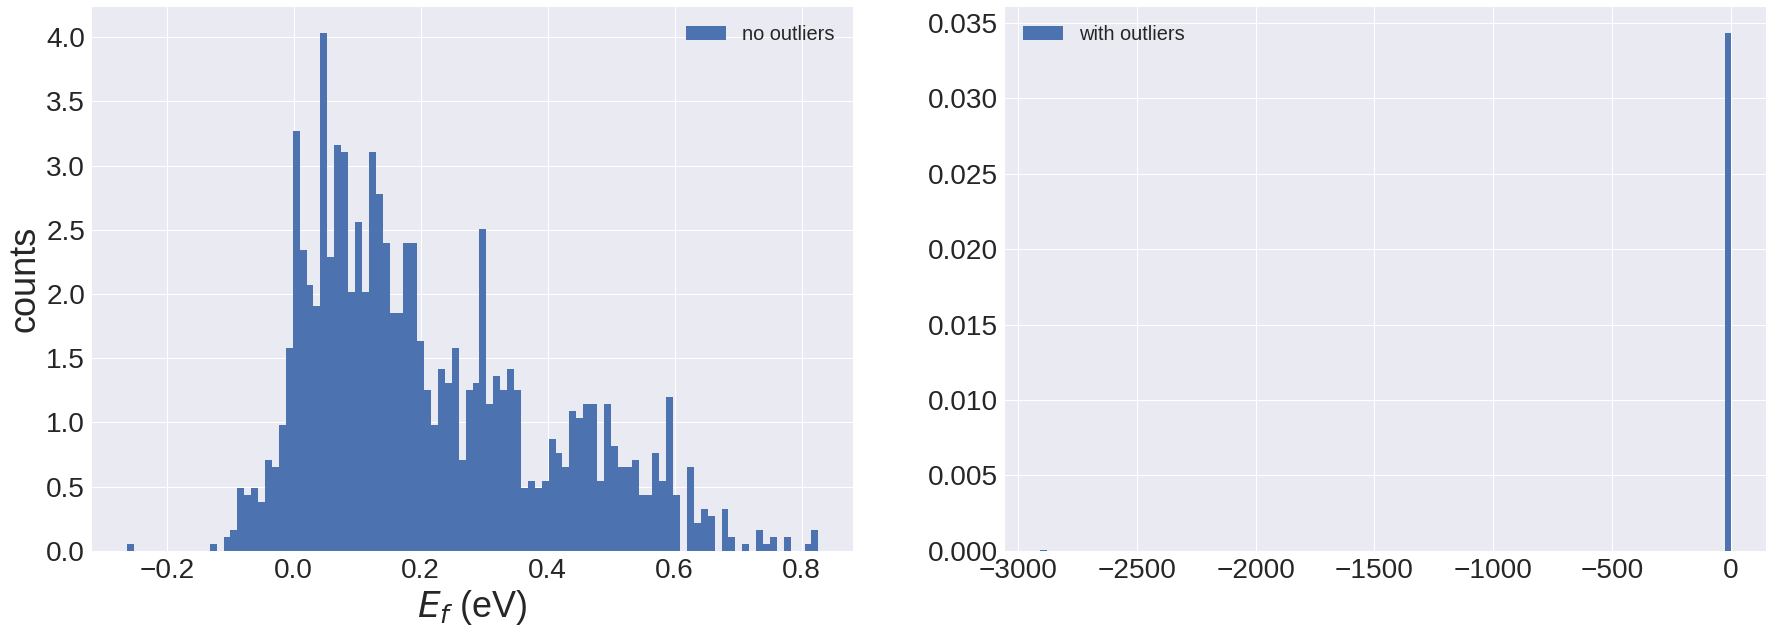

In [34]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS[(BS['EF']>-10) & (BS['EF']<2)]['EF'].hist(bins=100, ax=ax[0],density=True,label='no outliers')
h2=BS['EF'].hist(bins=100, ax=ax[1],density=True,label='with outliers')
ax[0].legend()
ax[0].set_xlabel('$E_f$ (eV)')
ax[0].set_ylabel('counts')
l = ax[1].legend()

In [37]:
OutInFirst = BS[(BS['EF']>-10) & (BS['EF']<2)]

In [38]:
OutInFirst

,,B,E0,V,deltak,encut,fit,ncrash,nelem,xc,B0,V0,atom_A,atom_B,atom_C,num_atom_A,num_atom_B,num_atom_C,num_atoms,EF
index,,,,,,,,,,,,,,,,,,,,
Co_pv6W_sv6.C14-BBA.FM,bulk C14-BBA.FM,293.907391 GPa,-10.000427,13.175678 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,293.907391,13.175678,Co_pv,W_sv,,6,6,0,12.0,-0.038167
Co_pv6W_sv6.C14-BBA.NM,bulk C14-BBA,293.949578 GPa,-10.000427,13.175679 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,293.949578,13.175679,Co_pv,W_sv,,6,6,0,12.0,-0.038167
Cr_pv6W_sv2.D0_19-A3B.FM,bulk D0_19-A3B.FM,244.993002 GPa,-10.002413,13.098145 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,244.993002,13.098145,Cr_pv,W_sv,,6,2,0,8.0,0.272512
Cr_pv6W_sv2.D0_19-A3B.NM,bulk D0_19-A3B,248.338396 GPa,-10.002452,13.093819 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,248.338396,13.093819,Cr_pv,W_sv,,6,2,0,8.0,0.272473
Cr_pv16Co_pv4W_sv10.sigma-CBAAC.FM,bulk sigma-CBAAC.FM,243.415325 GPa,-10.003732,13.525828 A,0.020,400,murnaghan volume_relaxed,0,3,PBE-PAW,243.415325,13.525828,Cr_pv,Co_pv,W_sv,16,4,10,30.0,0.247342
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Cr_pv20Co_pv2W_sv8.sigma-BAACA.FM,bulk sigma-BAACA.FM,251.093896 GPa,-9.988760,13.189987 A,0.020,400,murnaghan volume_relaxed,0,3,PBE-PAW,251.093896,13.189987,Cr_pv,Co_pv,W_sv,20,2,8,30.0,0.184951
Cr_pv20Co_pv2W_sv8.sigma-BAACA.NM,bulk sigma-BAACA,251.071094 GPa,-9.988760,13.189913 A,0.020,400,murnaghan volume_relaxed,0,3,PBE-PAW,251.071094,13.189913,Cr_pv,Co_pv,W_sv,20,2,8,30.0,0.184951
Co_pv13W_sv16.chi-ABAB.NM,bulk chi-ABAB,263.749012 GPa,-9.988843,14.051746 A,0.020,400,murnaghan volume_relaxed,0,2,PBE-PAW,263.749012,14.051746,Co_pv,W_sv,,13,16,0,29.0,0.282865


In [39]:
DATA = DATA[DATA['EF']>-10][DATA['EF']<10]

<ipython-input-39-64c614bcf2a6>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  DATA = DATA[DATA['EF']>-10][DATA['EF']<10]


In [40]:
DATA = DATA[ DATA['B0']<600 ]

<ipython-input-44-1ac9fe6ef218>:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  h1=BS[BS['B0']<600][BS['B0']>0]['B0'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')


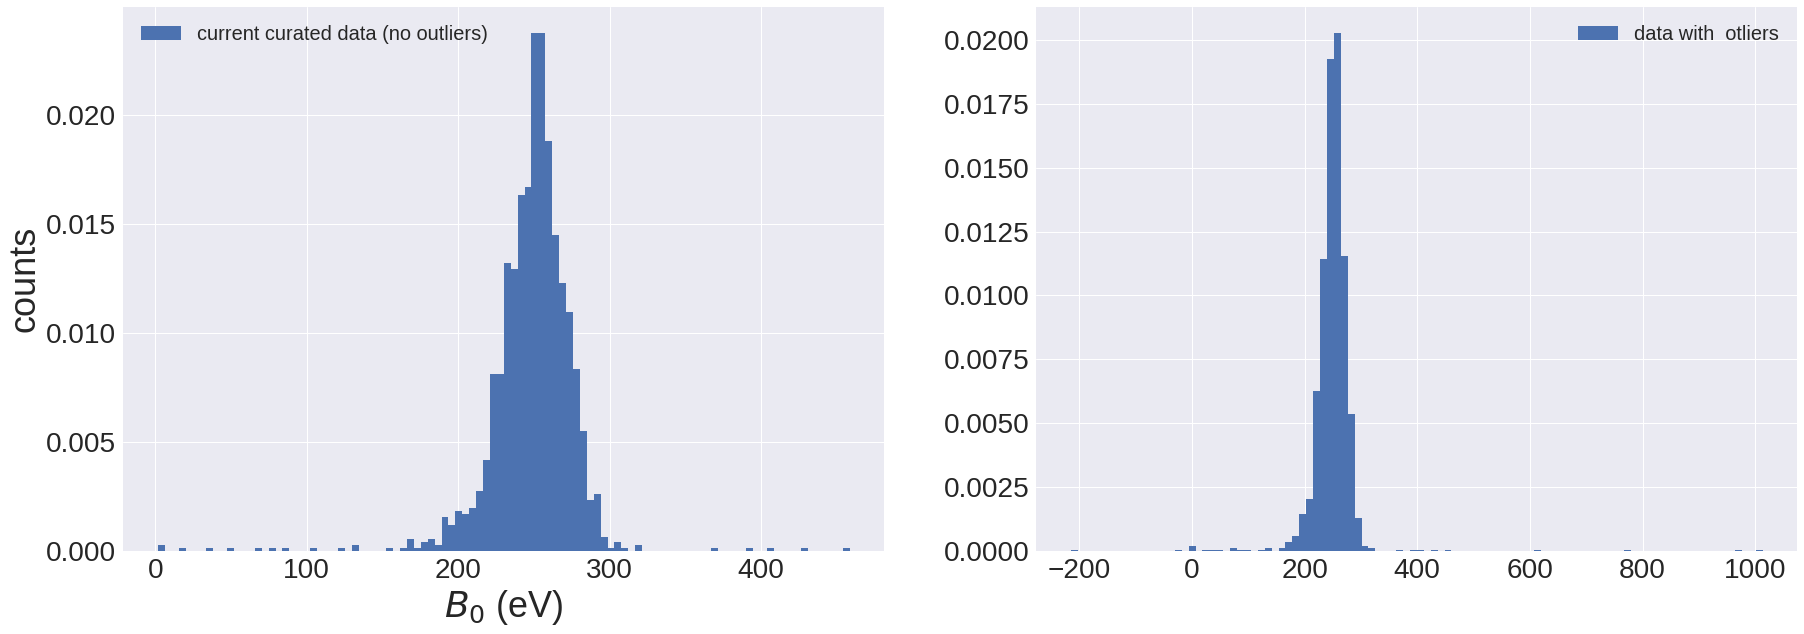

In [44]:
fig, ax = plt.subplots(1,2,figsize=(30,10))
h1=BS[BS['B0']<600][BS['B0']>0]['B0'].hist(bins=100, ax=ax[0],density=True,label='current curated data (no outliers)')
h1=BS['B0'].hist(bins=100, ax=ax[1],density=True,label='data with  otliers')
ax[0].legend()
ax[0].set_xlabel('$B_0$ (eV)')
ax[0].set_ylabel('counts')
l = ax[1].legend()

In [45]:
DATA['B0']=DATA[DATA['B0']<600][DATA['B0']>0]['B0']

## Brute Force features and target

In [53]:
X = DATA.drop(columns=['EF', 'B0','V0'])
Y = DATA['EF']

# Histograms of features

Are there more outliers ?

In [54]:
allcolumns = DATA.columns.drop(['B0', 'V0'])
columns = DATA.columns.drop(['B0', 'V0','EF'])

feature_titles = [ s.replace('NSC_','') for s in allcolumns ]
feature_titles = [s.replace('moments_','m_{') for s in feature_titles]
feature_titles = [s.replace('SIGMA_','\\sigma^{(') for s in feature_titles]
feature_titles = [s.replace('an_','a^{(') for s in feature_titles]
feature_titles = [s.replace('bn_','b^{(') for s in feature_titles]
feature_titles = [s.replace('Ainf_0','a^{\infty}') for s in feature_titles]
feature_titles = [s.replace('Binf_0','b^{\infty}') for s in feature_titles]
feature_titles = [s.replace('U_bind','U_{bind}') for s in feature_titles]
feature_titles = [s.replace('EF','E_F') for s in feature_titles]

for s, feature in enumerate(feature_titles):
    if '{(' in feature and ')}' not in feature:
        feature_titles[s] += ')}'
    if '{' in feature and '}' not in feature:
        feature_titles[s] += '}'
    feature_titles[s] = feature_titles[s].replace('{{','{')
    feature_titles[s] = feature_titles[s].replace('}}','}')
    feature_titles[s] = '$'+feature_titles[s]+'$'


feature_titles = pd.Series(feature_titles, index=allcolumns)

In [55]:
columns = DATA.columns.drop(['B0', 'V0', 'EF'])

In [59]:
DATA.dropna(axis=0,how='any',inplace=True)

<ipython-input-60-243bee6c2fe8>:5: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  ax.append( fig.add_subplot( len(columns)/5+1, 5, c+1 ) )


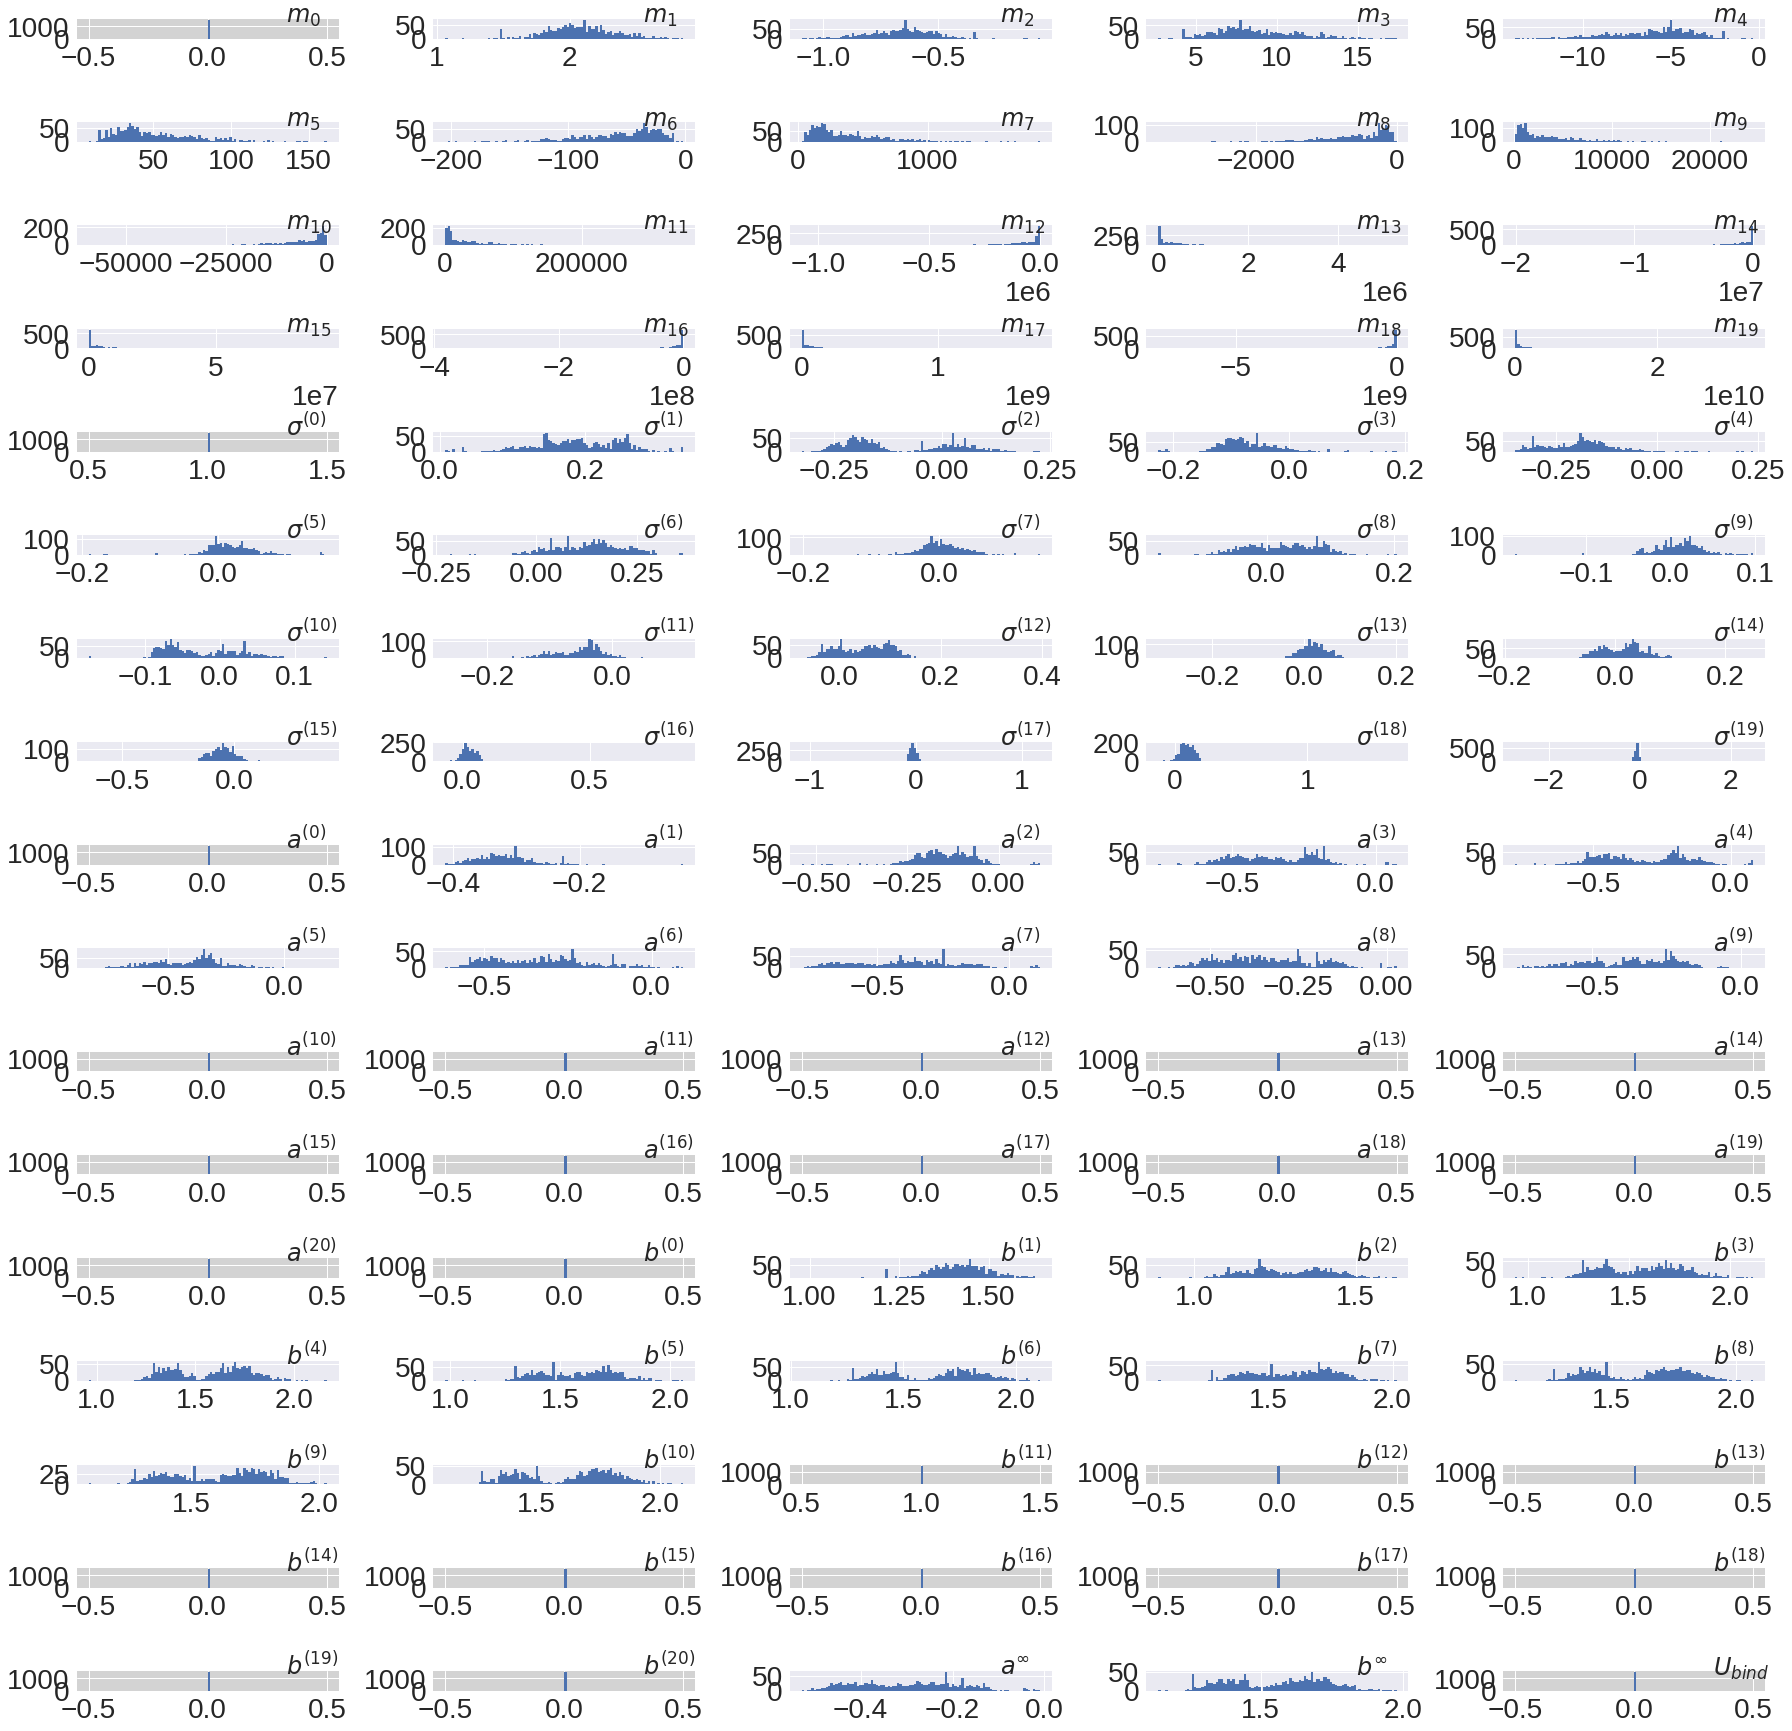

In [60]:
ax=[]
feature = []
fig = plt.figure(figsize=(25, 25))
for c, col in enumerate(columns):
    ax.append( fig.add_subplot( len(columns)/5+1, 5, c+1 ) )
    bins = ax[-1].hist(DATA[col], bins=100)
    
    if sum( bins[0]>0 ) > 1:
        feature.append(col)
    else:
        ax[-1].set_facecolor('lightgray')

for i,axis in enumerate(ax):
    axis.text(0.8, 0.8,feature_titles[i], fontsize=24 , transform=axis.transAxes)
#    axis.set_xlabel(feature_titles[i], fontsize=24)
    
fig.tight_layout()
    
    

<ipython-input-61-d099ecd7e5f8>:12: MatplotlibDeprecationWarning: Passing non-integers as three-element position specification is deprecated since 3.3 and will be removed two minor releases later.
  axg.append( fig.add_subplot( len(columns)/5+1, 5, a+1 ) )


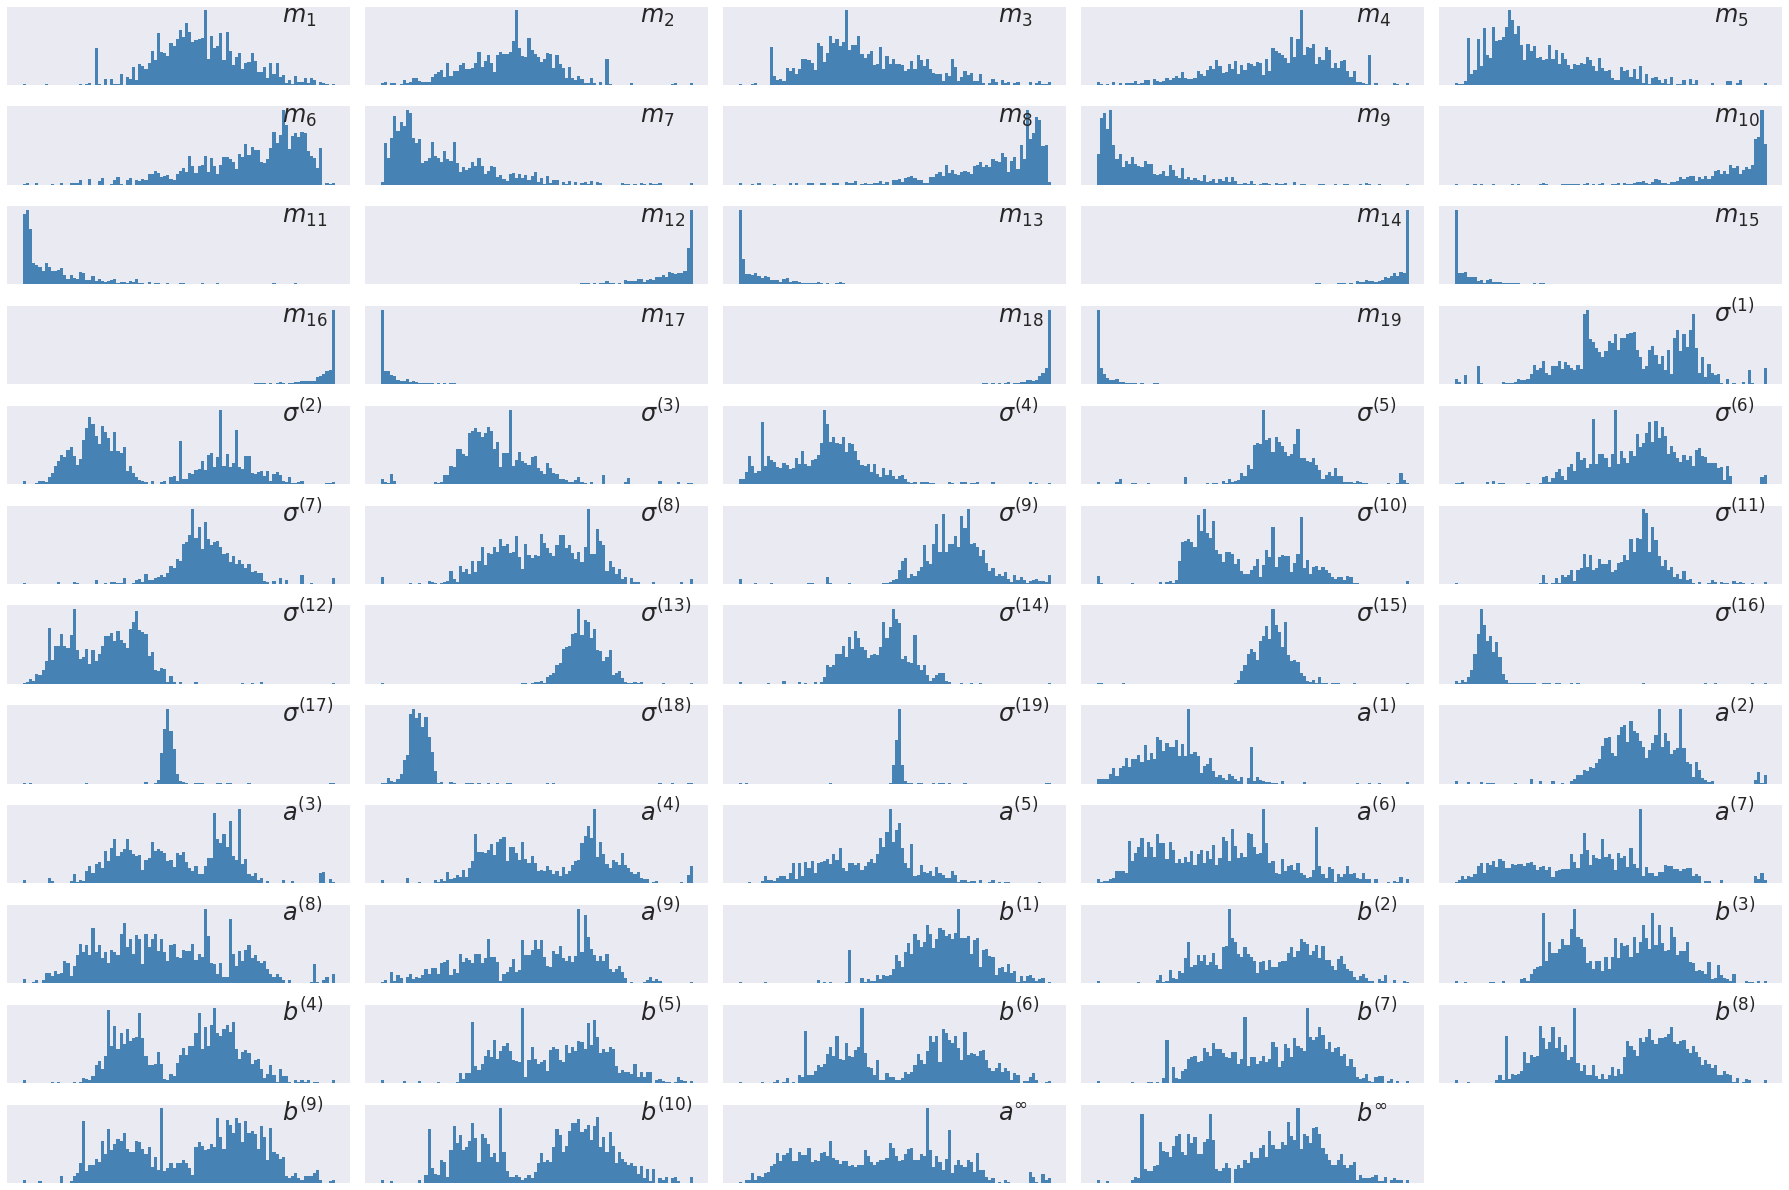

In [61]:
axg = []
fig = plt.figure(figsize=(25,25))
# remember feature_titles
a = 0
feature = []
for c, col in enumerate(columns):
    
    bins, edges = np.histogram(DATA[col], bins=100, density=True)
    # bins = plt.hist(DATA[col], bins=100)
    
    if sum( bins > 0 ) > 1:
        axg.append( fig.add_subplot( len(columns)/5+1, 5, a+1 ) ) 
        a+=1
        axg[-1].bar(edges[:-1], bins, color='steelblue',width=np.diff(edges))
        axg[-1].text(0.8, 0.8, feature_titles.iloc[c], fontsize=24 , transform=axg[-1].transAxes)
#        plt.xlabel(feature_titles[col],y=0.8 )
        axg[-1].set_yticks([])
        axg[-1].set_xticks([])
        feature.append(col)
        
           
fig.tight_layout()

Can somewhat classify the structures from the moments?

# Classification and weighting

In [63]:
with open('structures/binary/list.bcc', 'r') as f:
    listbcc = f.readlines()[0].strip().split(' ')

listbcc = ' '.join([re.sub('-.*','',s) for s in listbcc])

with open('structures/binary/list.fcc', 'r') as f:
    listfcc = f.readlines()[0].strip().split(' ')

listfcc = ' '.join([re.sub('-.*','',s) for s in listfcc])

with open('structures/binary/list.hcp', 'r') as f:
    listhcp = f.readlines()[0].strip().split(' ')

listhcp = ' '.join ([re.sub('-.*','',s) for s in listhcp])

Target_Class = pd.Series(
    DATA.index.str.split('.').map(lambda l: l[1]).map(lambda s: s.split('-')[0]),
    index=DATA.index
)

Target_Class[Target_Class.map(lambda s: s in listhcp)]='hcp'
Target_Class[Target_Class.map(lambda s: s in listfcc)]='fcc'
Target_Class[Target_Class.map(lambda s: s in listbcc)]='bcc'

Target_Class[DATA.index.str.contains('SQS-fcc')] = 'fcc'
Target_Class[DATA.index.str.contains('SQS-L12')] = 'fcc'

Target_Class[    
    Target_Class.str.contains('Al42W') |\
    Target_Class.str.contains('Al9Co2') |\
    Target_Class.str.contains('Al5W') |\
    Target_Class.str.contains('Al12W') |\
    Target_Class.str.contains('Al4W') |\
    Target_Class.str.contains('Al5Co2')
] = 'others'


FileNotFoundError: [Errno 2] No such file or directory: 'structures/binary/list.bcc'

In [ ]:
plt.hist(Target_Class[(Target_Class != 'others') & (Target_Class != 'delta')], bins=80, density = True, width=0.5, align='left', color = 'purple')
xticks = plt.xticks(rotation=90, fontsize=36)
yticks = plt.yticks([], fontsize=36)
plt.ylabel('Density Count', fontsize=36)
plt.savefig('graph/class_counts.pdf',bbox_inches='tight')

In [24]:
Elements = pd.concat((BS['atom_A'],BS['atom_B'], BS['atom_C'])).replace('',np.nan).dropna()

In [25]:
Elements = Elements.map(lambda s: s.replace('_pv', ''))

Text(0, 0.5, 'density count')

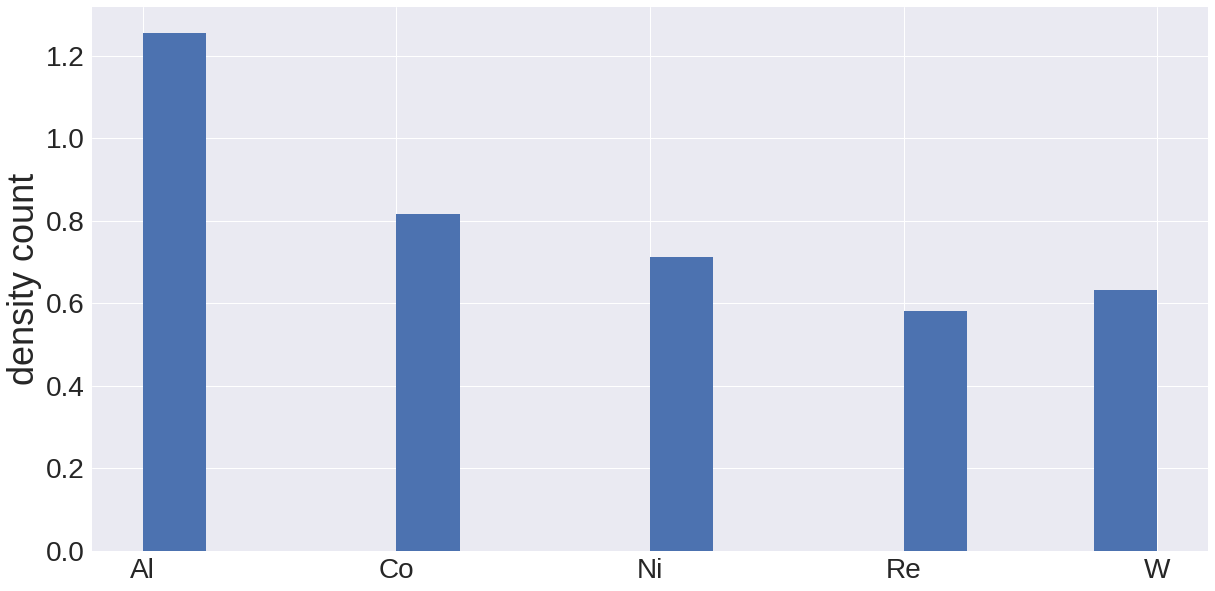

In [26]:
plt.hist(Elements, bins =16, density=True)
plt.ylabel('density count')

([<matplotlib.axis.XTick at 0x7f89142c5be0>,
 [Text(1.1, 0, 'Pure'), Text(2.1, 0, 'Binary'), Text(2.9, 0, 'Ternary')])

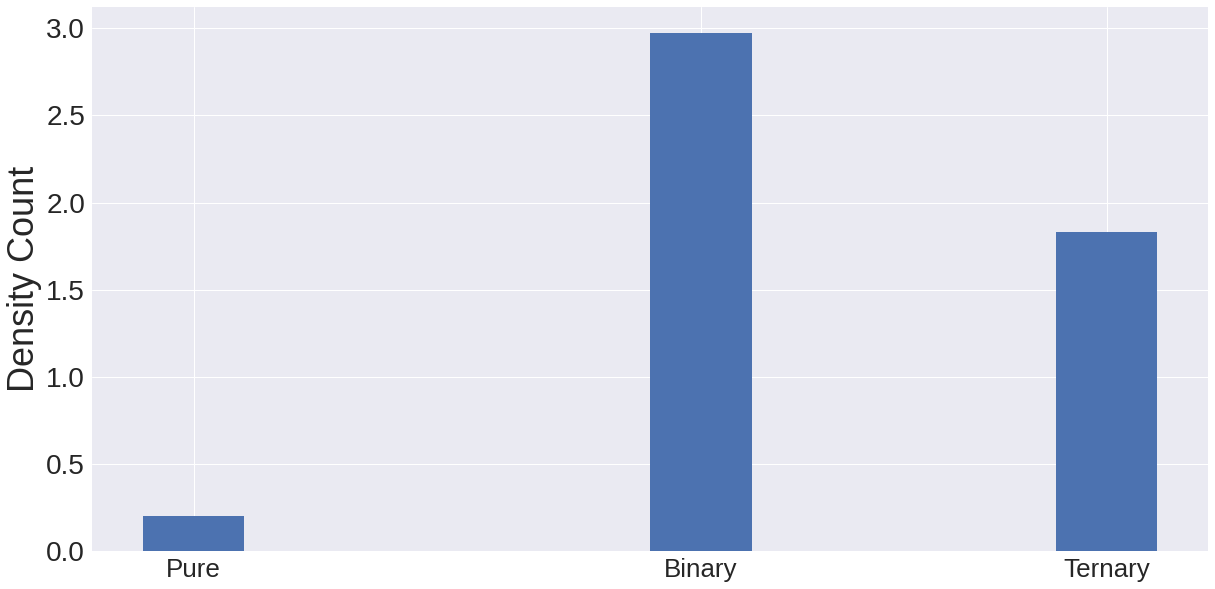

In [27]:
H = plt.hist(BS['nelem'], density=True)
plt.ylabel('Density Count')
plt.xticks([1.1, 2.1, 2.9], ['Pure', 'Binary', 'Ternary'], fontsize=26)

as we see here, the dataset is quite vadly classified, this will lead to wrong results when I try to regress A15 properties using the rest of the dataset. ths classes should be taken into account and give the weights to the regressors

In [28]:
Classes = pd.DataFrame(Target_Class.values, columns=['Class'], index=DATA.index)
Target_Class_Count = Target_Class.value_counts()
Classes['Weights'] = 1/(Target_Class_Count[Target_Class]/Target_Class_Count.sum()).values #Target_Class_Count.sum()

In [29]:
# only the features with some distributino:

print(feature)

['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4', 'NSC_moments_5', 'NSC_moments_6', 'NSC_moments_7', 'NSC_moments_8', 'NSC_moments_9', 'NSC_moments_10', 'NSC_moments_11', 'NSC_moments_12', 'NSC_moments_13', 'NSC_moments_14', 'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3', 'NSC_SIGMA_4', 'NSC_SIGMA_5', 'NSC_SIGMA_6', 'NSC_SIGMA_7', 'NSC_SIGMA_8', 'NSC_SIGMA_9', 'NSC_SIGMA_10', 'NSC_SIGMA_11', 'NSC_SIGMA_12', 'NSC_SIGMA_13', 'NSC_SIGMA_14', 'NSC_an_1', 'NSC_an_2', 'NSC_an_3', 'NSC_an_4', 'NSC_an_5', 'NSC_an_6', 'NSC_an_7', 'NSC_bn_1', 'NSC_bn_2', 'NSC_bn_3', 'NSC_bn_4', 'NSC_bn_5', 'NSC_bn_6', 'NSC_bn_7', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind']


## Some kind of structure map

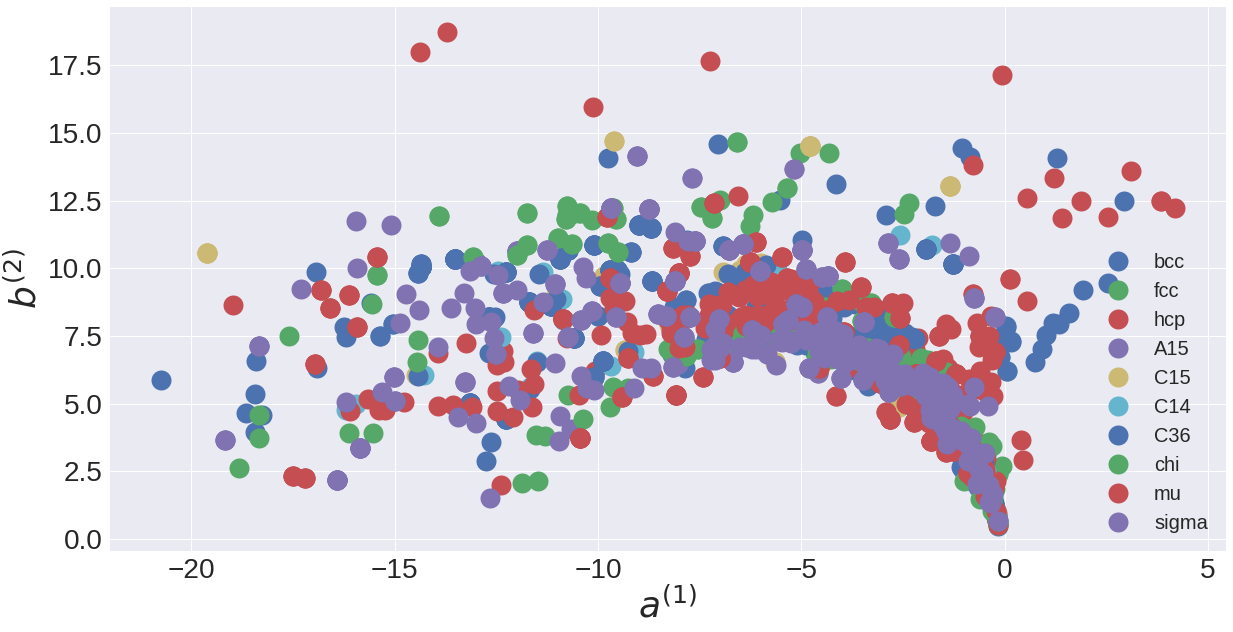

In [30]:
fig = plt.figure(figsize=(20, 10))
class_of_interest = ['bcc','fcc','hcp','A15','C15','C14','C36','chi','mu','sigma']
for i, clase in enumerate(class_of_interest):
    A1 = DATA['NSC_moments_2'][Classes['Class']==clase]
    B2 = np.sqrt( 
        DATA['NSC_moments_3'][Classes['Class']==clase] -
        DATA['NSC_moments_2'][Classes['Class']==clase]**2 -1
    )
    plt.plot(A1,B2, 'o', ms=20, label=clase)
plt.xlabel('$a^{(1)}$')
plt.ylabel('$b^{(2)}$')
#plt.xticks([])
#plt.yticks([])
plt.legend()
    
    

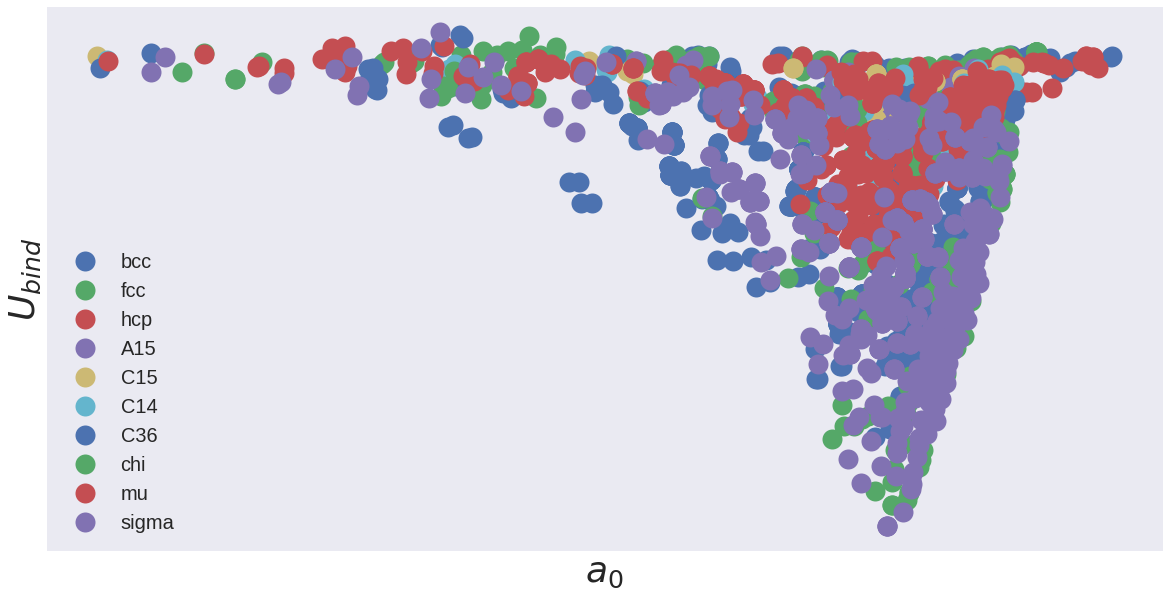

In [31]:
fig = plt.figure(figsize=(20, 10))
class_of_interest = ['bcc','fcc','hcp','A15','C15','C14','C36','chi','mu','sigma']
for i, clase in enumerate(class_of_interest):
    pltX = DATA['NSC_an_1'][Classes['Class']==clase]
    pltY = DATA['NSC_U_bind'][Classes['Class']==clase]
    plt.plot(pltX,pltY, 'o', ms=20, label=clase)
plt.xlabel('$a_0$')
plt.ylabel('$U_{bind}$')
plt.xticks([])
plt.yticks([])
plt.legend()

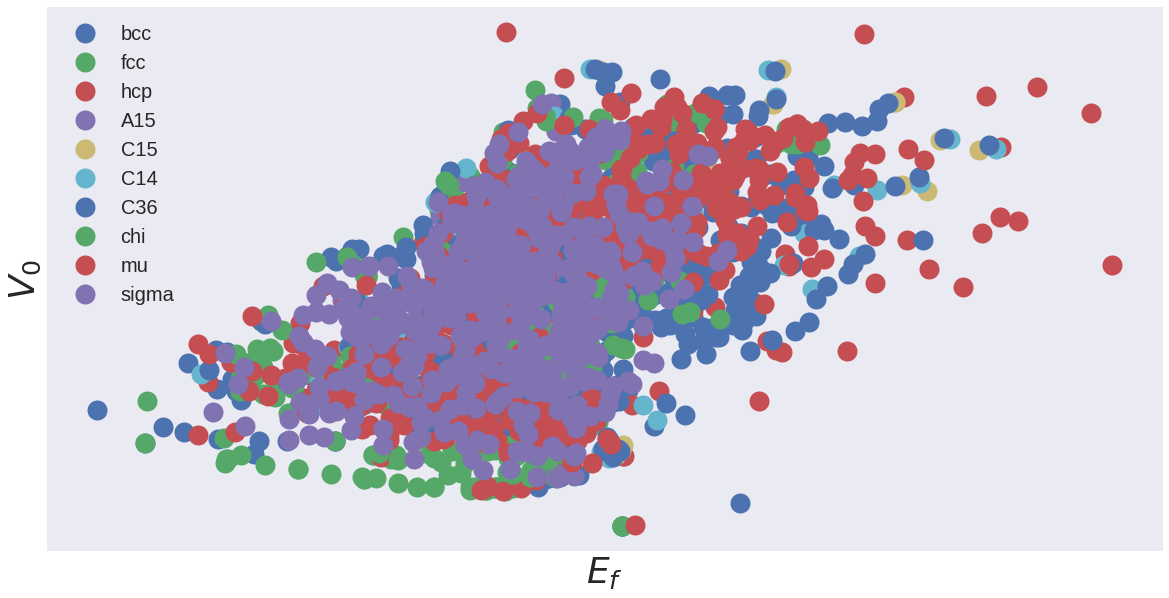

In [32]:
fig = plt.figure(figsize=(20, 10))
class_of_interest = ['bcc','fcc','hcp','A15','C15','C14','C36','chi','mu','sigma']
for i, clase in enumerate(class_of_interest):
    pltX = DATA['EF'][Classes['Class']==clase]
    pltY = DATA['V0'][Classes['Class']==clase]
    plt.plot(pltX,pltY, 'o', ms=20, label=clase)
plt.xlabel('$E_f$')
plt.ylabel('$V_0$')
plt.xticks([])
plt.yticks([])
plt.legend()

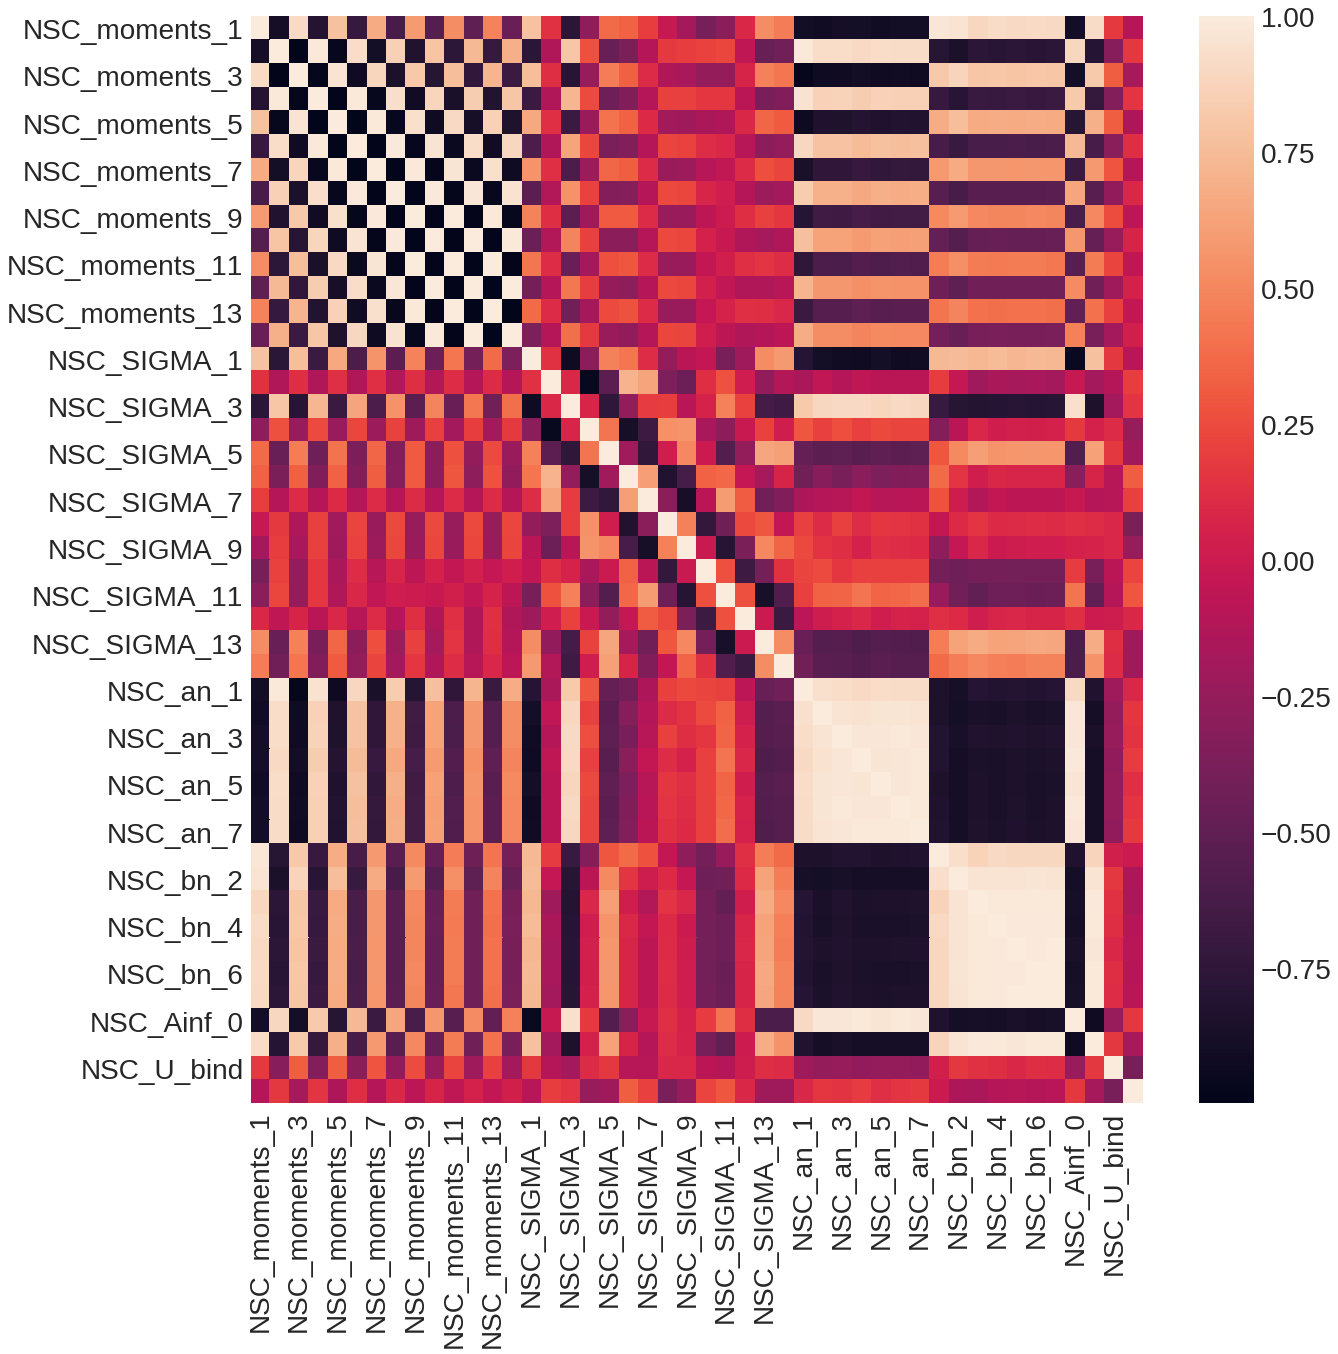

In [33]:
CORRS = DATA[feature+['EF']].corr()
CORRS.dropna(how='all',inplace=True)
CORRS.dropna(inplace=True, axis=1)
ax = plt.figure(figsize=(20,20)).add_axes()
HM = heatmap(CORRS, ax=ax)

I remove this because the scatterplot on so many features is really big and hard to visualize
```python
scatterplot = pd.plotting.scatter_matrix(DATA[feature],figsize=(30,30), diagonal='kde')
for a in range(scatterplot.shape[0]):
#    scatterplot[0,a].set_xlabel(axis.get_xlabel(), rotation=45) #,xy=(-1,0), xycoords='offset') 
    scatterplot[a,0].set_ylabel(scatterplot[a,0].get_ylabel(), rotation=30) 
    scatterplot[-1,a].set_xlabel(scatterplot[a,0].get_xlabel(), rotation=30)
plt.gcf().tight_layout()
```

# Test with Random Forest Regressor

In [34]:
CORRS['EF'][CORRS['EF']<1].index.values

array(['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4',
       'NSC_moments_5', 'NSC_moments_6', 'NSC_moments_7', 'NSC_moments_8',
       'NSC_moments_9', 'NSC_moments_10', 'NSC_moments_11',
       'NSC_moments_12', 'NSC_moments_13', 'NSC_moments_14',
       'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3', 'NSC_SIGMA_4',
       'NSC_SIGMA_5', 'NSC_SIGMA_6', 'NSC_SIGMA_7', 'NSC_SIGMA_8',
       'NSC_SIGMA_9', 'NSC_SIGMA_10', 'NSC_SIGMA_11', 'NSC_SIGMA_12',
       'NSC_SIGMA_13', 'NSC_SIGMA_14', 'NSC_an_1', 'NSC_an_2', 'NSC_an_3',
       'NSC_an_4', 'NSC_an_5', 'NSC_an_6', 'NSC_an_7', 'NSC_bn_1',
       'NSC_bn_2', 'NSC_bn_3', 'NSC_bn_4', 'NSC_bn_5', 'NSC_bn_6',
       'NSC_bn_7', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind'], dtype=object)

In [35]:
CORRS['EF'][CORRS['EF']<1].index.values

array(['NSC_moments_1', 'NSC_moments_2', 'NSC_moments_3', 'NSC_moments_4',
       'NSC_moments_5', 'NSC_moments_6', 'NSC_moments_7', 'NSC_moments_8',
       'NSC_moments_9', 'NSC_moments_10', 'NSC_moments_11',
       'NSC_moments_12', 'NSC_moments_13', 'NSC_moments_14',
       'NSC_SIGMA_1', 'NSC_SIGMA_2', 'NSC_SIGMA_3', 'NSC_SIGMA_4',
       'NSC_SIGMA_5', 'NSC_SIGMA_6', 'NSC_SIGMA_7', 'NSC_SIGMA_8',
       'NSC_SIGMA_9', 'NSC_SIGMA_10', 'NSC_SIGMA_11', 'NSC_SIGMA_12',
       'NSC_SIGMA_13', 'NSC_SIGMA_14', 'NSC_an_1', 'NSC_an_2', 'NSC_an_3',
       'NSC_an_4', 'NSC_an_5', 'NSC_an_6', 'NSC_an_7', 'NSC_bn_1',
       'NSC_bn_2', 'NSC_bn_3', 'NSC_bn_4', 'NSC_bn_5', 'NSC_bn_6',
       'NSC_bn_7', 'NSC_Ainf_0', 'NSC_Binf_0', 'NSC_U_bind'], dtype=object)

In [36]:
model1 = Pipeline([
    ('imputer', SimpleImputer()), # For the failed structures
    ('model', RandomForestRegressor(n_estimators=150, n_jobs=-1))
])

In [37]:
model1.fit(X,Y)

Pipeline(steps=[('imputer', SimpleImputer()),
                ('model', RandomForestRegressor(n_estimators=150, n_jobs=-1))])

In [38]:
Predict = model1.predict(X)
rmsefull = mean_squared_error(DATA['EF'], Predict,squared=False)

In [39]:
rmsefull

0.06001781219718623

In [40]:
DATA['EF'].max()

1.0291720000000009

some test-train split

In [41]:
Xtrain, Xtest, w_train, w_test,  Ytrain, Ytest = train_test_split(X, Classes['Weights'], Y, random_state = 123496)

In [42]:
model1.fit(Xtrain, Ytrain)

Pipeline(steps=[('imputer', SimpleImputer()),
                ('model', RandomForestRegressor(n_estimators=150, n_jobs=-1))])

In [43]:
Predict_Train = model1.predict(Xtrain)
Predict_Test = model1.predict(Xtest)

In [44]:
rmsetrain = mean_squared_error(Ytrain, Predict_Train,squared=False)
rmsetest = mean_squared_error(Ytest, Predict_Test,squared=False)

In [45]:
rmsetrain
rmsetest

bond_specific_global_rmse = [('full', rmsefull), ('train', rmsetrain), ('test', rmsetest)]

%store bond_specific_global_rmse

Stored 'bond_specific_global_rmse' (list)


In [46]:
len(X.columns)

65

In [47]:
model1['model'].feature_importances_

array([0.        , 0.00995803, 0.01698261, 0.03312955, 0.00427559,
       0.00991809, 0.00386473, 0.00323283, 0.0054106 , 0.00220786,
       0.00339347, 0.00293466, 0.00269415, 0.00508241, 0.00283954,
       0.        , 0.00975462, 0.02797044, 0.01589017, 0.02370005,
       0.02194362, 0.09391356, 0.01665917, 0.05355561, 0.01293937,
       0.01868515, 0.0962911 , 0.02466652, 0.02148823, 0.04356306,
       0.        , 0.01501412, 0.01346781, 0.01916767, 0.02345161,
       0.02130224, 0.01640669, 0.00971288, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.01671137, 0.01294565, 0.01042298,
       0.01702769, 0.01255581, 0.01509741, 0.03583374, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.01201763, 0.01181909, 0.15010082])

Text(0, 0.5, 'feature')

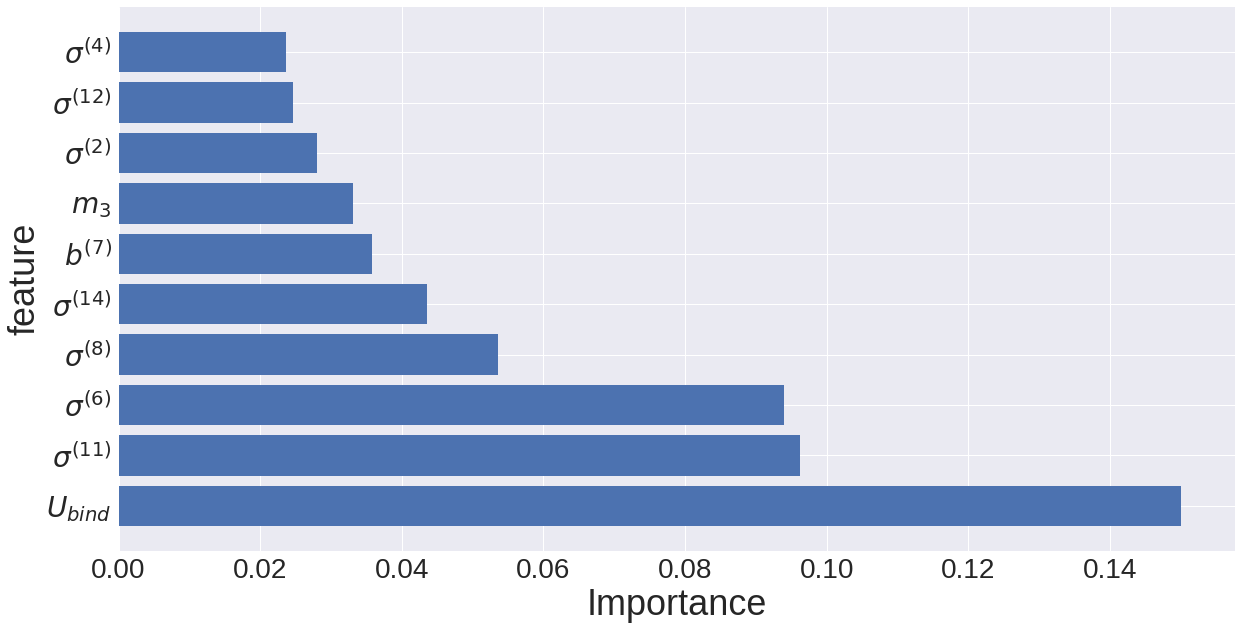

In [48]:
features_with_importances = pd.DataFrame({'features':X.columns, 'importancies':model1['model'].feature_importances_}).sort_values(by='importancies', ascending=False)
plt.barh(features_with_importances[:10]['features'], features_with_importances[:10]['importancies'])
labels = plt.gca().set_yticklabels(feature_titles[features_with_importances[:10]['features']].values)
plt.xlabel('Importance')
plt.ylabel('feature')

Fit using sample weights

In [49]:
model1_sample_wights = copy.deepcopy(model1)

In [50]:
model1_sample_wights.fit(Xtrain,Ytrain, model__sample_weight=w_train)

Pipeline(steps=[('imputer', SimpleImputer()),
                ('model', RandomForestRegressor(n_estimators=150, n_jobs=-1))])

In [51]:
Predict_weights = model1_sample_wights.predict(X)

Text(0, 0.5, 'feature')

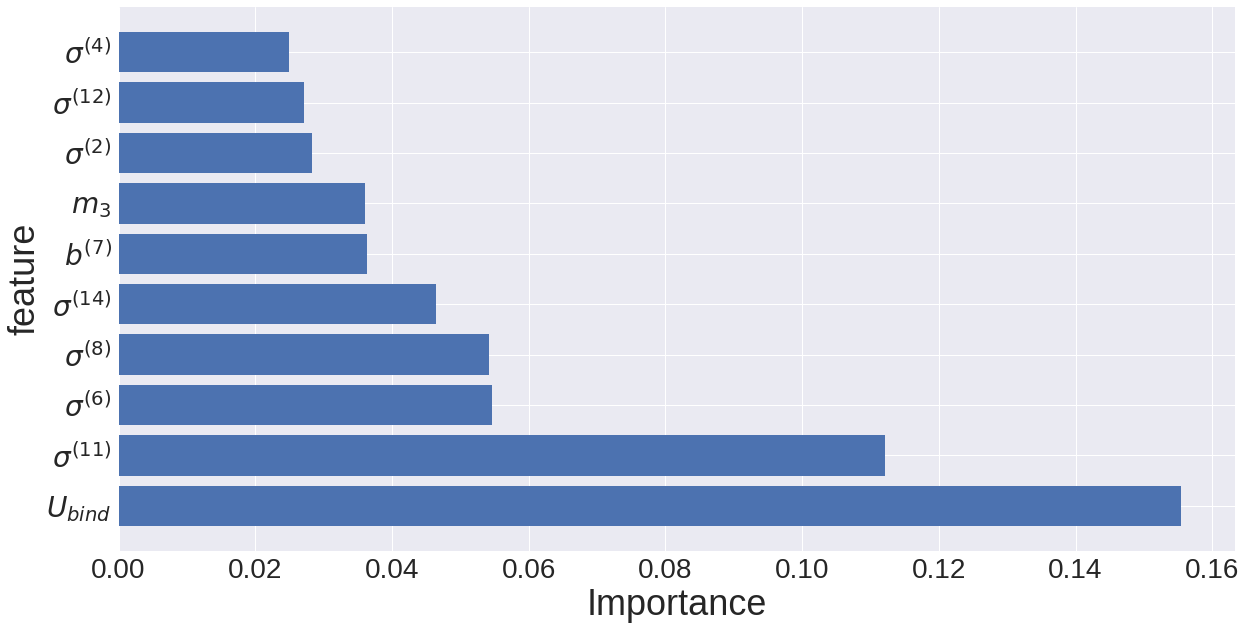

In [52]:
features_with_importances_weights = pd.DataFrame({'features':X.columns, 'importancies':model1_sample_wights['model'].feature_importances_}).sort_values(by='importancies', ascending=False)
plt.barh(features_with_importances_weights[:10]['features'], features_with_importances_weights[:10]['importancies'])
labels = plt.gca().set_yticklabels(feature_titles[features_with_importances[:10]['features']].values)
plt.xlabel('Importance')
plt.ylabel('feature')

In [53]:
mean_squared_error(Y, Predict_weights,squared=False)

0.0749909620225746

# can I predict some specific tcp phase ?

In [54]:
BOP[BOP.index.str.contains('delta')]

,NSC_moments_0,NSC_moments_1,NSC_moments_2,NSC_moments_3,NSC_moments_4,NSC_moments_5,NSC_moments_6,NSC_moments_7,NSC_moments_8,NSC_moments_9,...,NSC_bn_9,NSC_bn_10,NSC_bn_11,NSC_bn_12,NSC_bn_13,NSC_bn_14,NSC_bn_15,NSC_Ainf_0,NSC_Binf_0,NSC_U_bind
index,,,,,,,,,,,,,,,,,,,,,
Al.delta.FM,0.0,23.633736,-146.781857,2239.461429,-26493.228571,367213.428571,-5.061414e+06,7.257332e+07,-1.056891e+09,1.566896e+10,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-3.169757,7.382303,-29.161953
Re.delta.FM,0.0,7.654611,-7.271527,105.102936,-219.495286,1863.499286,-5.832329e+03,3.886208e+04,-1.526608e+05,9.020043e+05,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.492302,3.029725,-670.609906
W.delta.FM,0.0,7.897529,-8.337573,112.804371,-263.539714,2117.092143,-7.337510e+03,4.721846e+04,-2.017829e+05,1.174962e+06,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.539865,3.095719,-687.237225


In [55]:
type(model1)

sklearn.pipeline.Pipeline

In [56]:
def PredictPhase(
    features,
    _DATA,
    phase='C15',
    trainsplit = 0.1 ,
    _model=model1,
    _sample_weights = None,
    name=None,
    dotheplot = True,
    problemth = None
) :
    """this function train on the rest of the dataset + a protion of the target phase
    
    Paramaeters
    ===========
    features: list of features to use at training
    _DATA: dataset
    phase: target phase
    trainsplit: split of target phase to add on train set
    _model: regression model
    _sample_weights: sample weights
    dotheplot: weather to make the plot or not.
    plrblemth: threshold to get problematic phases
    
    Returns:
    trainsplit: fraction of target phase used at train (just for convenience.)
    r2scoretcp: r2score over test part of split.
    """
#    DATA = pd.concat((FEATURES, TARGET), axis=1)
    phase_index = _DATA.index.str.contains(phase)
    PXTRAIN, PXTEST, PYTRAIN, PYTEST = train_test_split(
        _DATA.loc[phase_index][features],
        _DATA.loc[phase_index]['EF'],
        train_size = trainsplit,
        shuffle = True,
        random_state=1234
    )
    XTRAIN = _DATA.drop(index=PYTEST.index)[features]#, columns=['EF'])
    YTRAIN = _DATA['EF'][XTRAIN.index]
    if any(_sample_weights != None):
        TRAINW = _sample_weights.loc[XTRAIN.index]
        if isinstance(_model, sklearn.pipeline.Pipeline):
            fitparams = {_model.steps[-1][0]+'__'+'sample_weight': TRAINW}
        else:
            fitparams = {'sample_weight': TRAINW}
    else: 
        fitparams={}
    
    _model.fit(XTRAIN,YTRAIN, **fitparams)
    YPREDICT = _model.predict(XTRAIN)
    TCPPREDICT = _model.predict(PXTEST)
    TCPERRORS = TCPPREDICT - PYTEST
    ERRORS = YPREDICT - YTRAIN
    RMSE_full = mean_squared_error(YTRAIN, YPREDICT, squared=False)
    RMSE_tcp = mean_squared_error(PYTEST,TCPPREDICT, squared=False)
    rmsestring_full = 'RMSE score = {:.3f}'.format(RMSE_full)
    rmsestring_tcp = 'RMSE score = {:.3f}'.format(RMSE_tcp)
    if dotheplot:
        fig,ax = plt.subplots(1,2)
        ax[0].hist(np.abs(TCPERRORS), density=True, bins = 100, color='red', label='Predict on '+phase+' '+rmsestring_tcp)
        ax[0].hist(np.abs(ERRORS), density = True, bins = 100,alpha=.5, label = 'The rest of compounds '+rmsestring_full)
        ax[0].set_xlabel('$|E_f ^{train} - E_f ^{predict}|$  ')
        ax[0].set_ylabel('density count')
        ax[0].legend()

        ax[1].plot(YPREDICT,YTRAIN,'or',label='The rest of the systems')
        ax[1].plot(TCPPREDICT,PYTEST,'ok',alpha=0.5, label='prediction on '+phase)
        ax[1].set_xlabel('Train Values')
        ax[1].set_ylabel('Predicted Values')
        ax[1].plot(DATA['EF'],DATA['EF'],'g',label='data')
        ax[1].legend()
        if name == None:
            tit = fig.suptitle(type(_model))
        else:
            tit = fig.suptitle(name)
        fig.tight_layout()
    if problemth is not None:
        PROBLEMATIC = PYTEST[np.abs(TCPERRORS)>problemth]
        # I still need to get the position where to get a banner with the name of the problematic sample
        
    return trainsplit, RMSE_tcp
        

# split, r2 = PredictPhase(Bestfeats, DATA, phase='C15', trainsplit=0.5,  _sample_weights=Classes['Weights'], problemth=0.3)

## Helper Function

Stored 'list_BOP' (list)


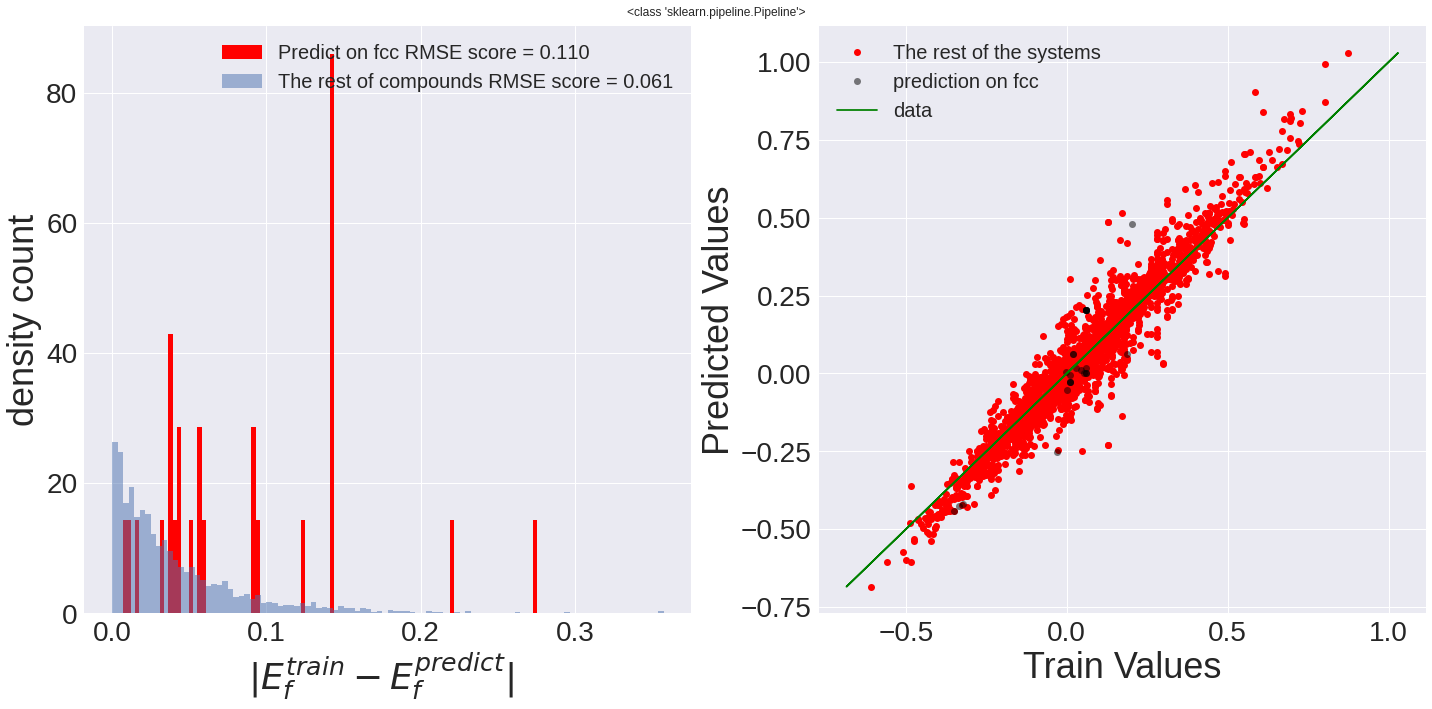

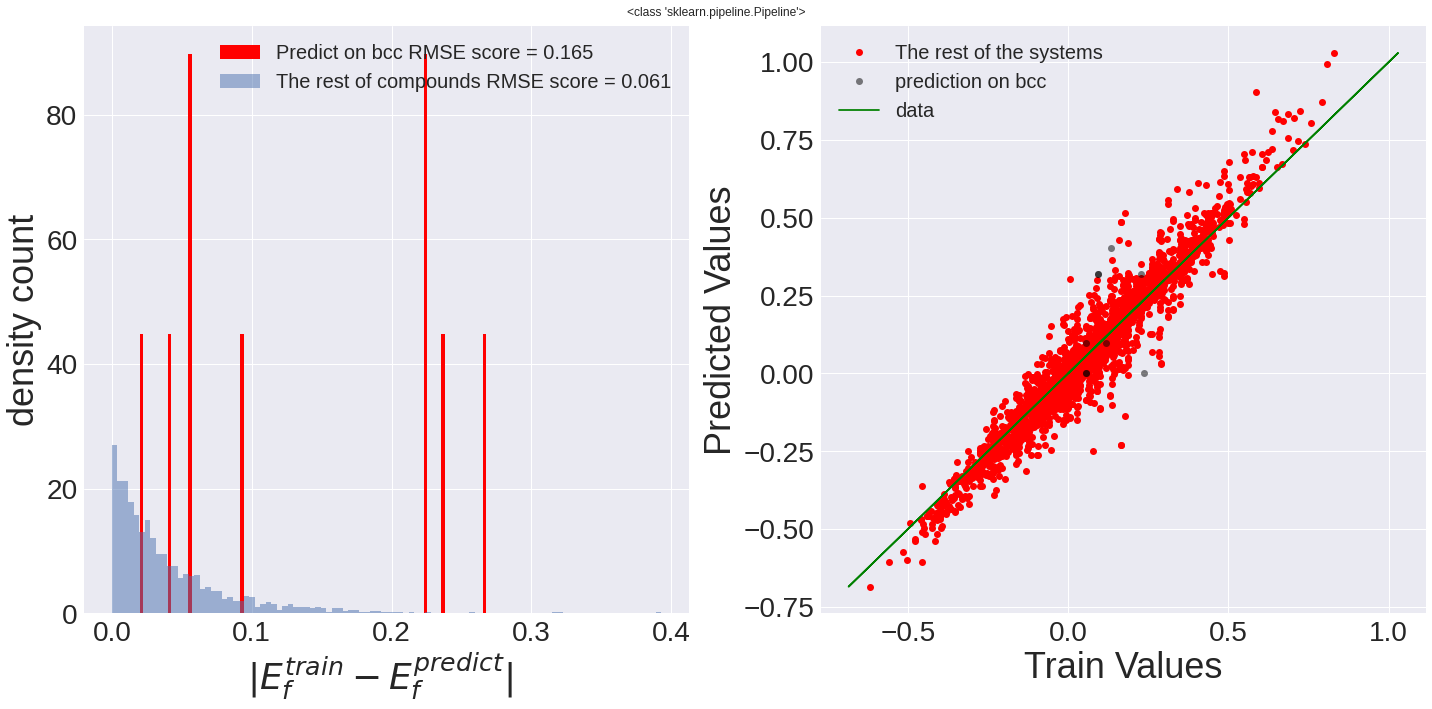

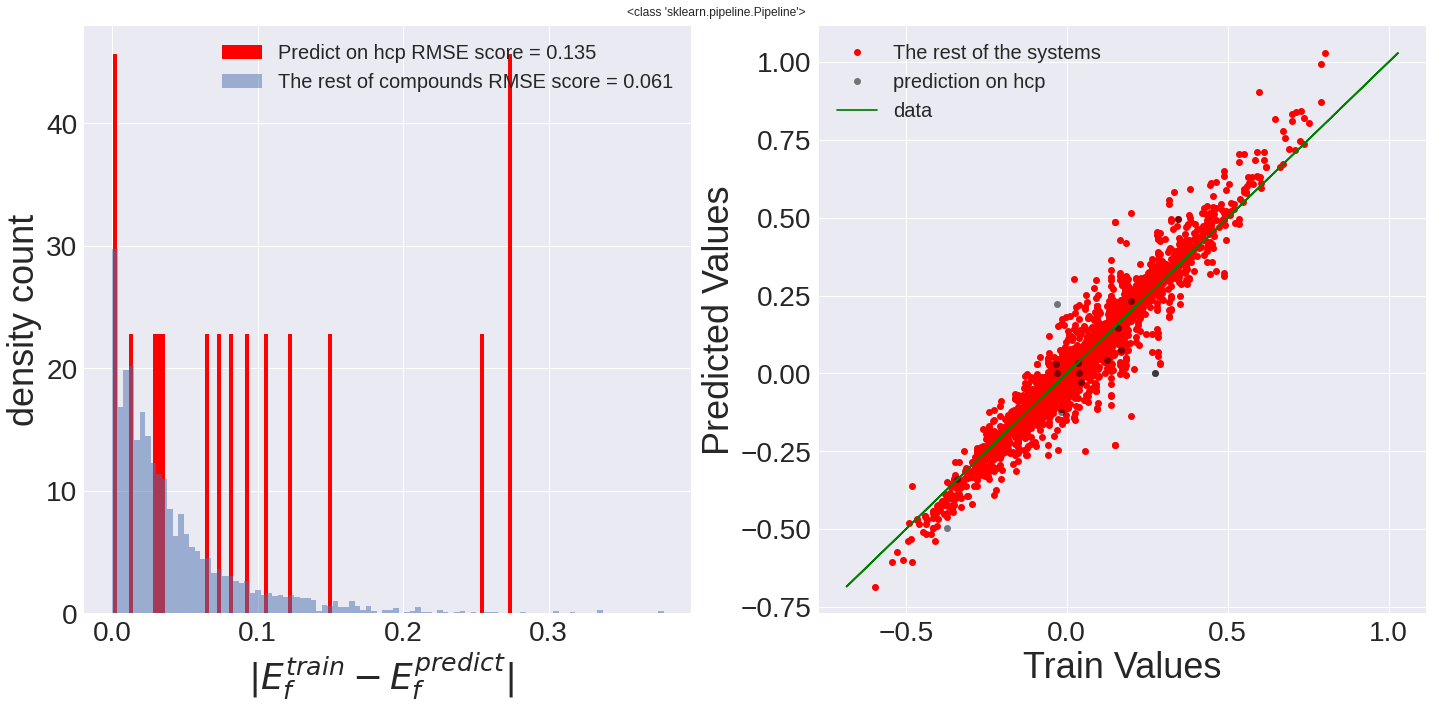

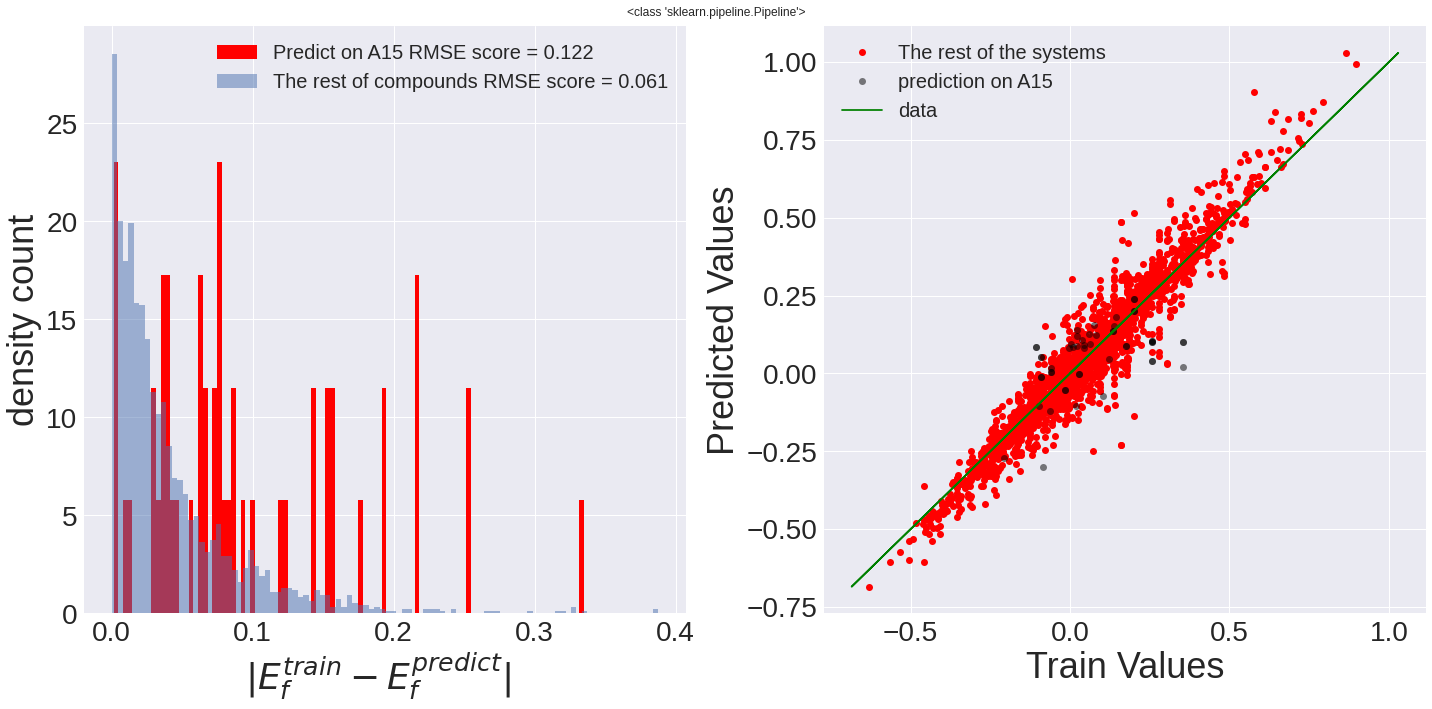

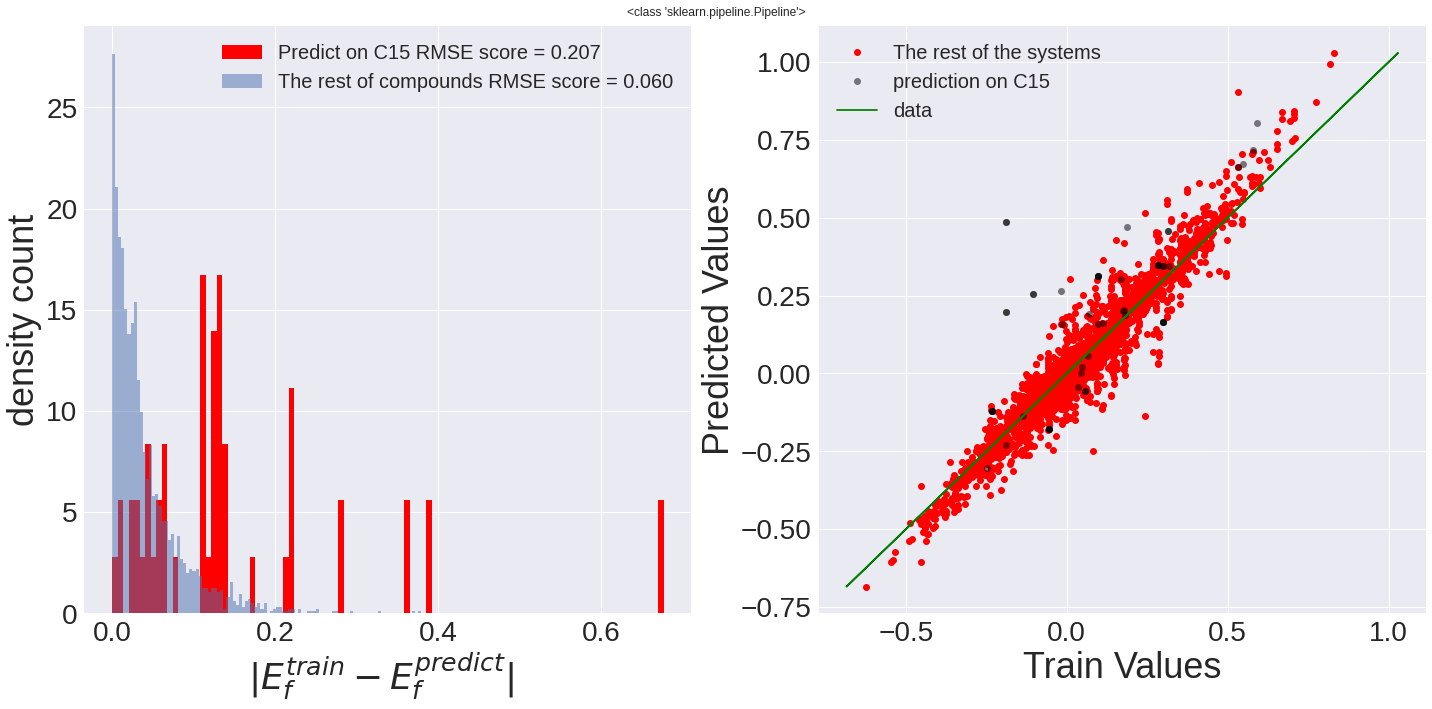

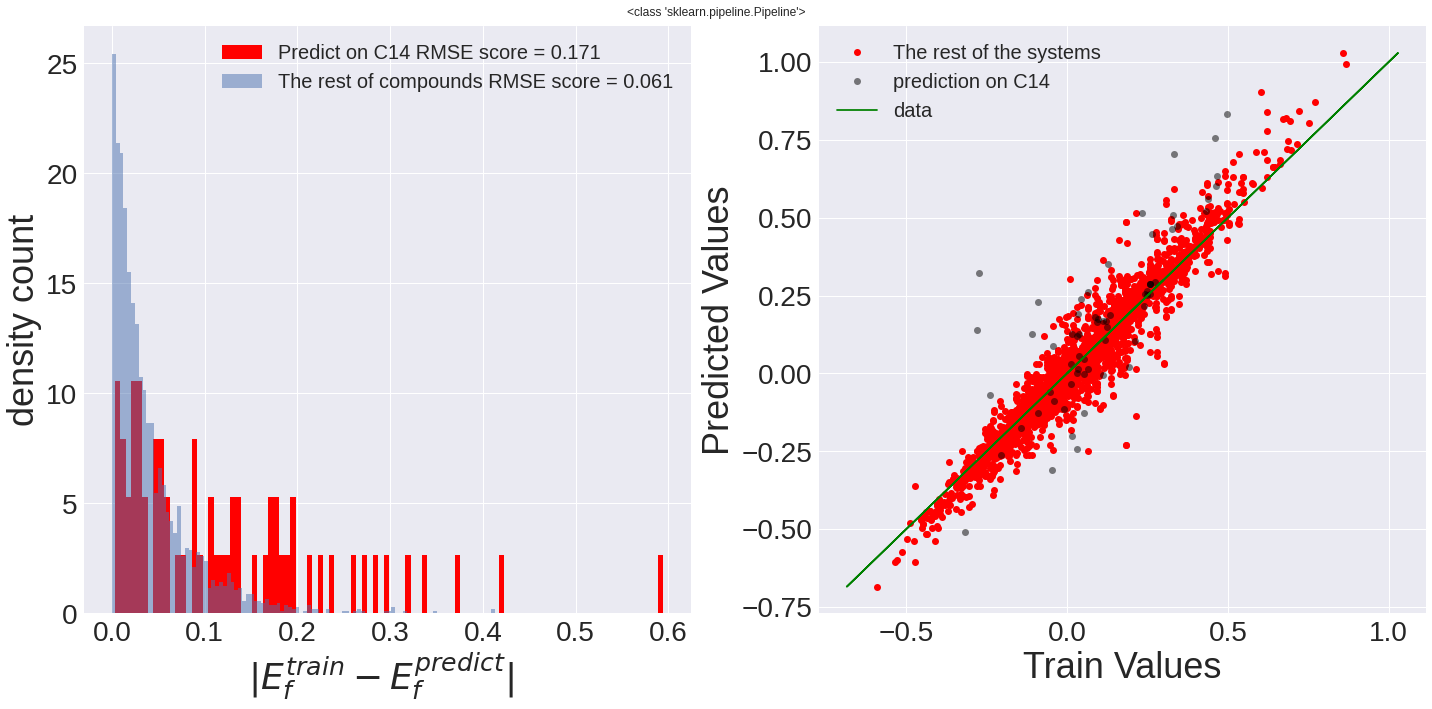

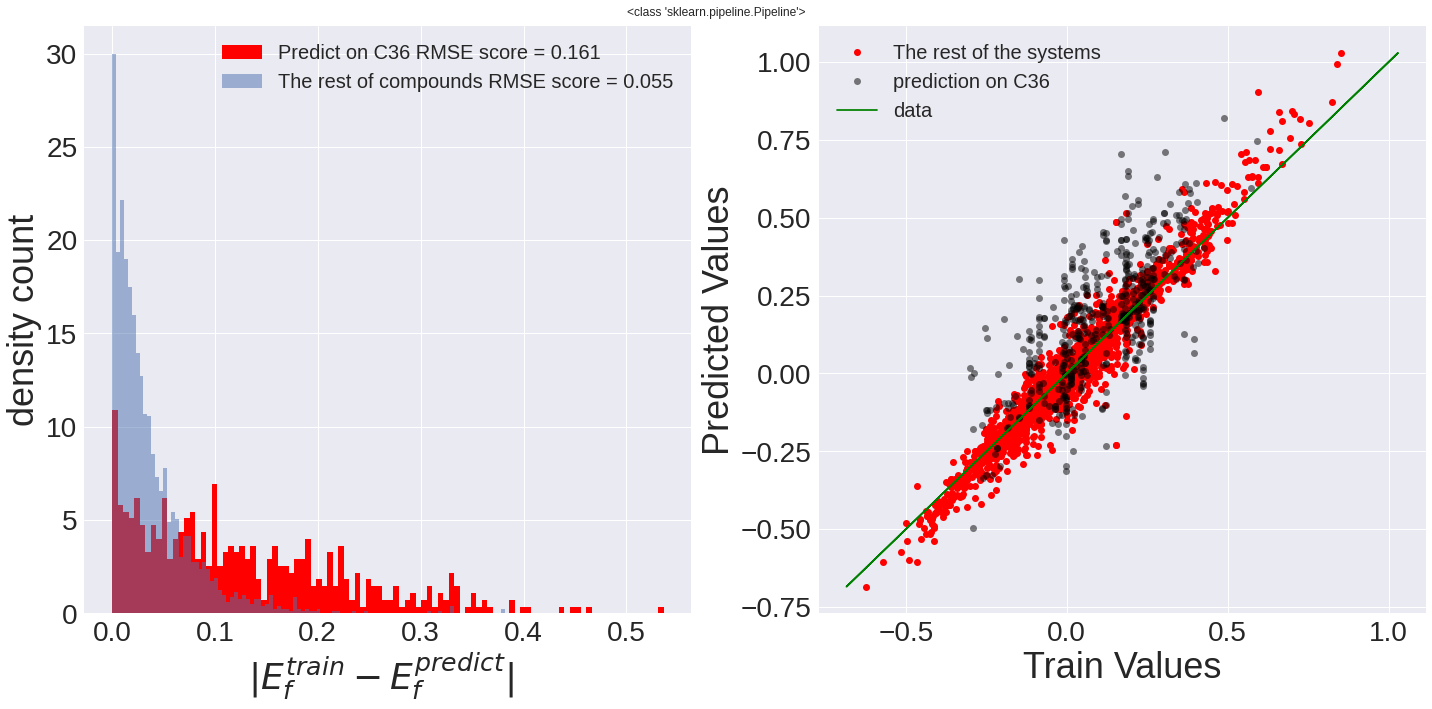

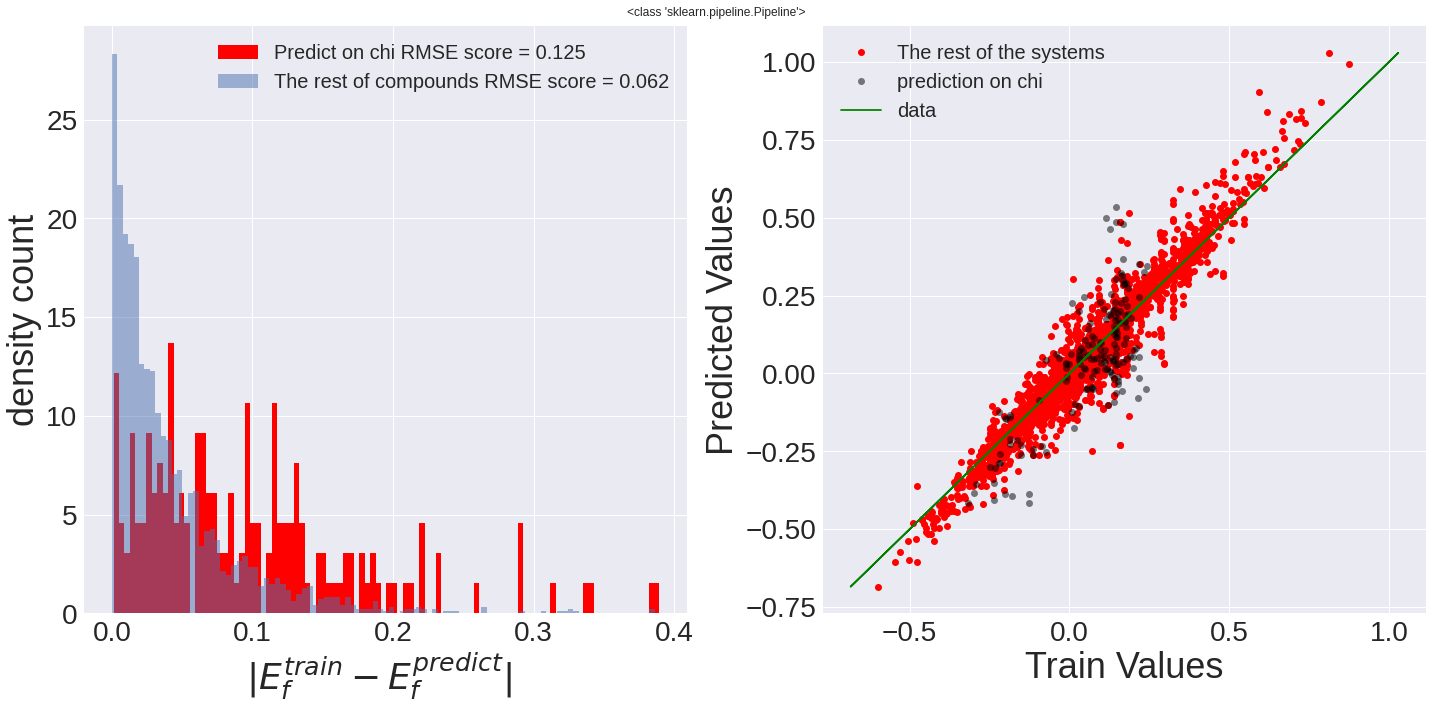

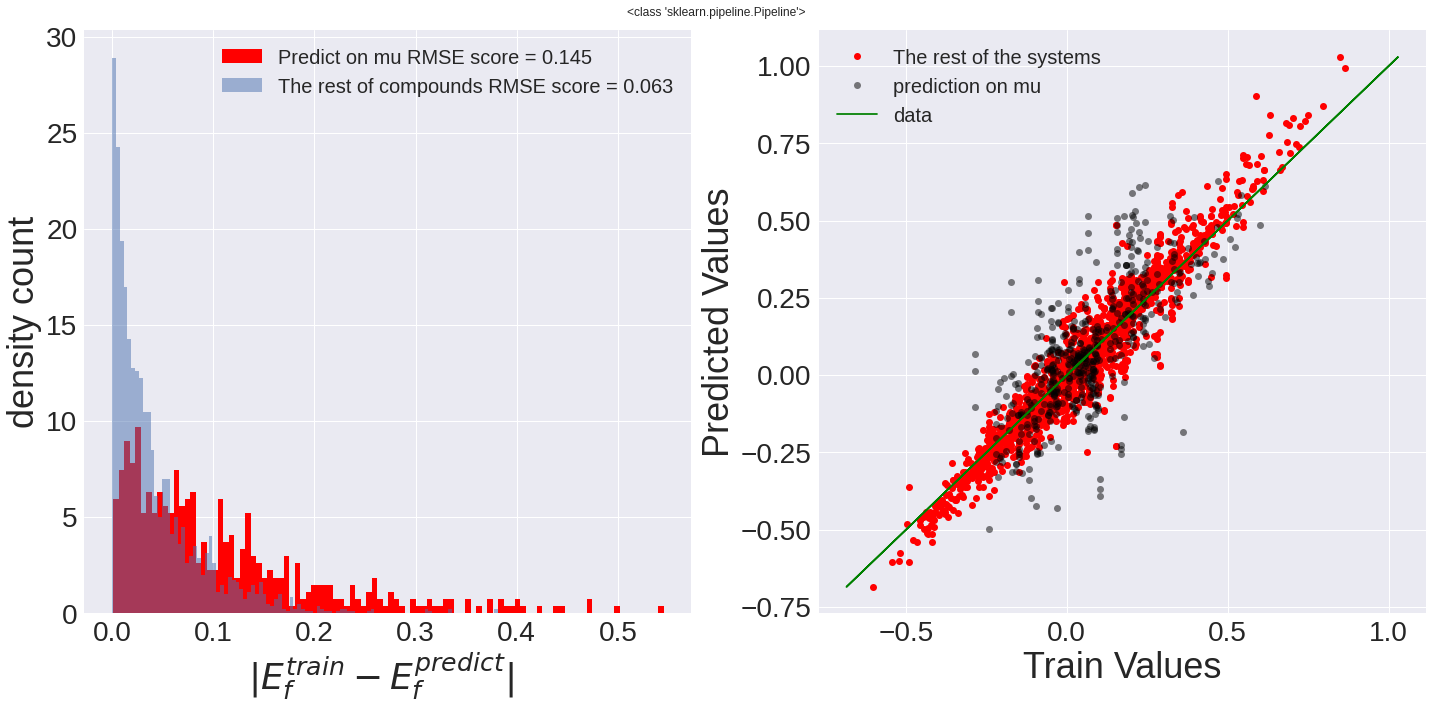

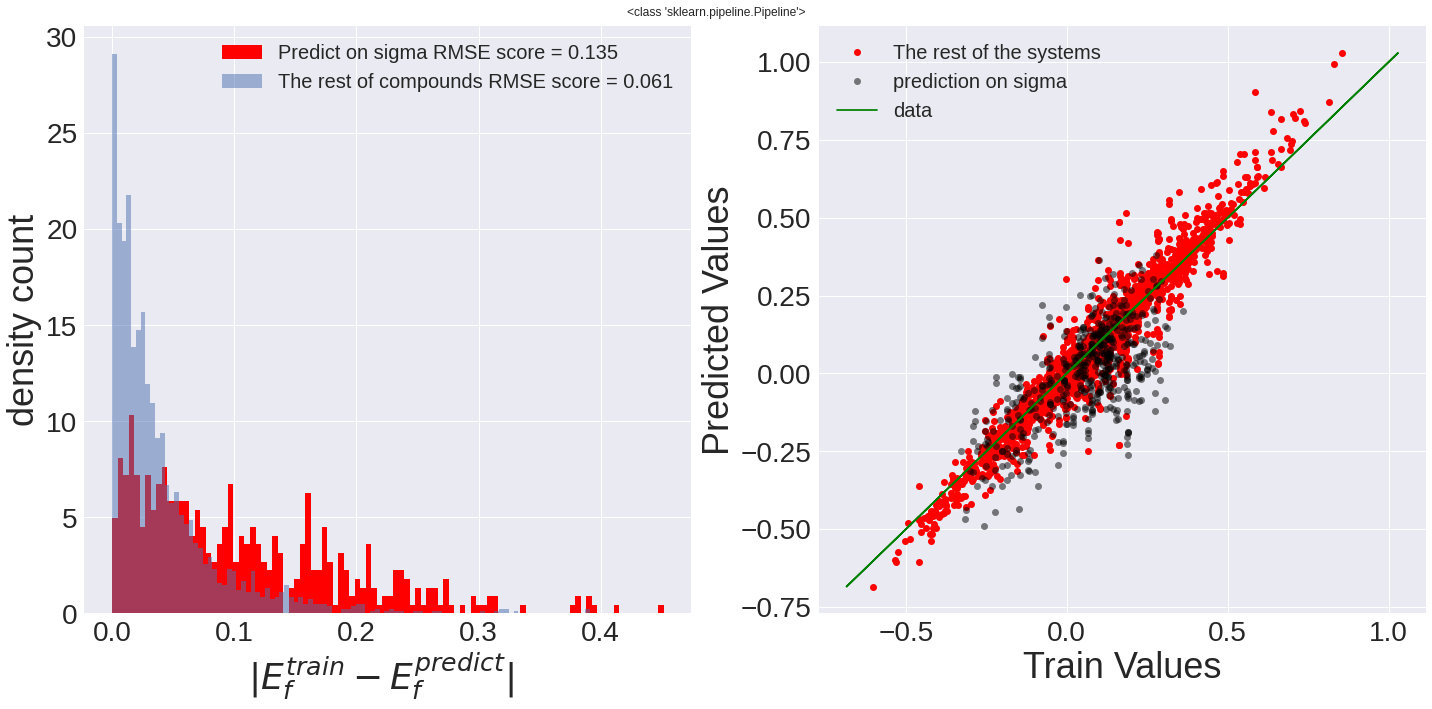

In [57]:
Interesting_classes = ['fcc', 'bcc', 'hcp', 'A15', 'C15', 'C14', 'C36', 'chi', 'mu', 'sigma']

list_BOP  = []
for p, phase in enumerate(Interesting_classes):
    list_BOP.append(
        PredictPhase(features_with_importances_weights[:10]['features'], DATA, phase=phase, _sample_weights=Classes['Weights'])
    )
#        list_BOP.append( test(features_with_importances_weights[:10]['features'], DATA, phase=phase, _sample_weights=Classes['Weights'], name='Random Forest Regressor Weighted') )
%store list_BOP

# make test-train split within the want-to-predict phase

In [58]:
def incsplit(bestlist, alllist, phase='fcc', dotheplot=True):
    fitfull = []
    fitbest = []
    trainsplit = [0.1, 0.2, 0.3, 0.4,0.5, 0.6, 0.7, 0.8]
    progress = tqdm_notebook(trainsplit, ncols = 800, ascii = True)
    for splitsize in progress:
        dum, rmseful = PredictPhase(alllist, DATA, phase=phase,
                                  trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                  dotheplot=False)
        fitfull.append(rmseful)
        dum, rmsebest = PredictPhase(bestlist, DATA, phase=phase,
                                   trainsplit = splitsize, _sample_weights=Classes['Weights'],
                                   dotheplot=False)
        fitbest.append(rmsebest)
    if dotheplot:
        fig, ax = plt.subplots()
        ax.plot(trainsplit, fitfull, '--o', label = 'full features')
        ax.plot(trainsplit, fitbest, '--o', label = 'only best features')
        ax.set_ylabel('RMSE on predictions for {:s}'.format(phase), fontsize=36)
        ax.set_xlabel('split fraction on target phase', fontsize=36)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=36)
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=36)
        ax.legend()
        fig.savefig(f'graphs/incsplits_{phase}.pdf')
    return trainsplit, fitbest, fitfull

In [59]:
performances  = {}
Interesting_classes = ['A15', 'C15', 'C14', 'C36', 'chi', 'mu', 'sigma']

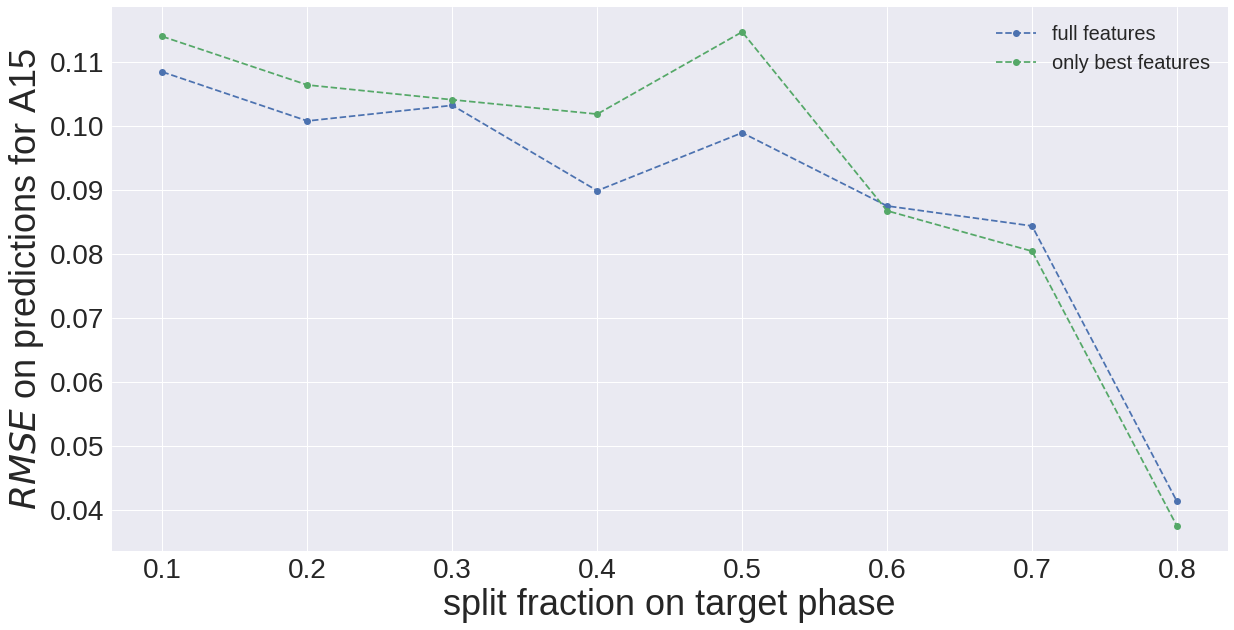

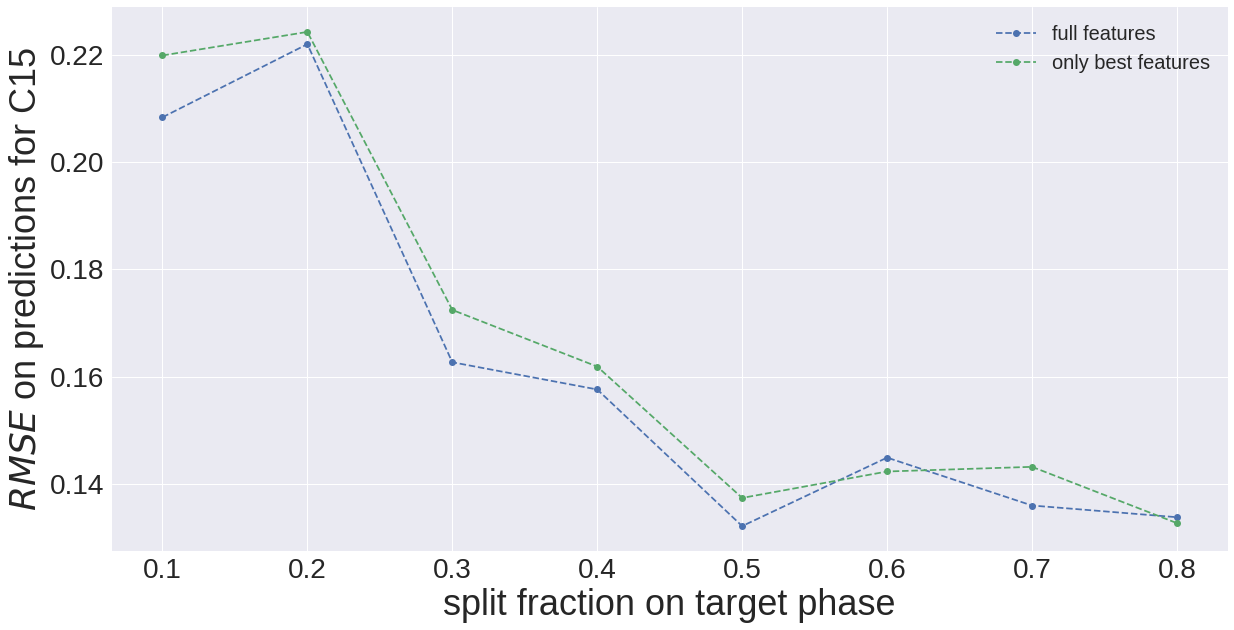

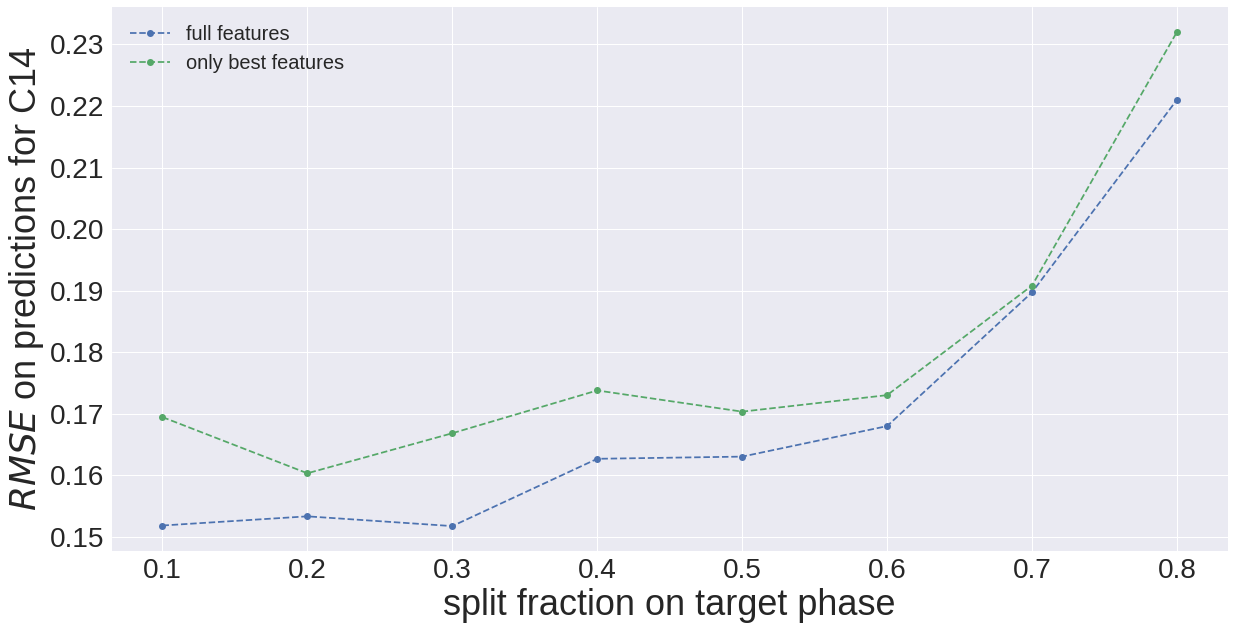

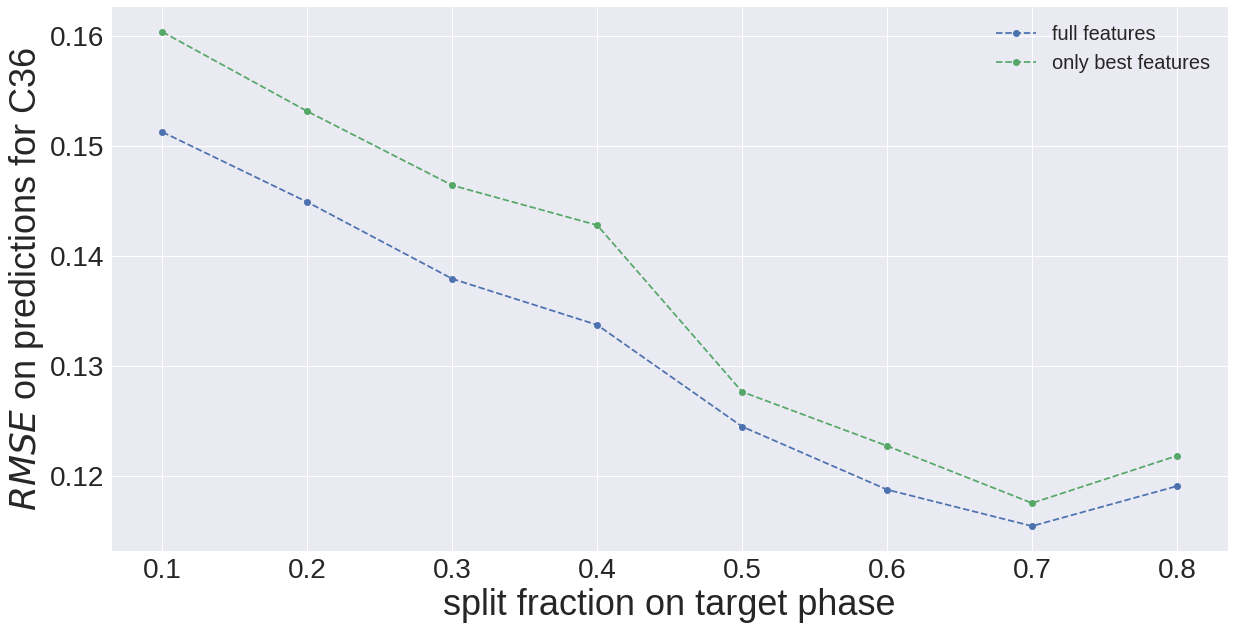

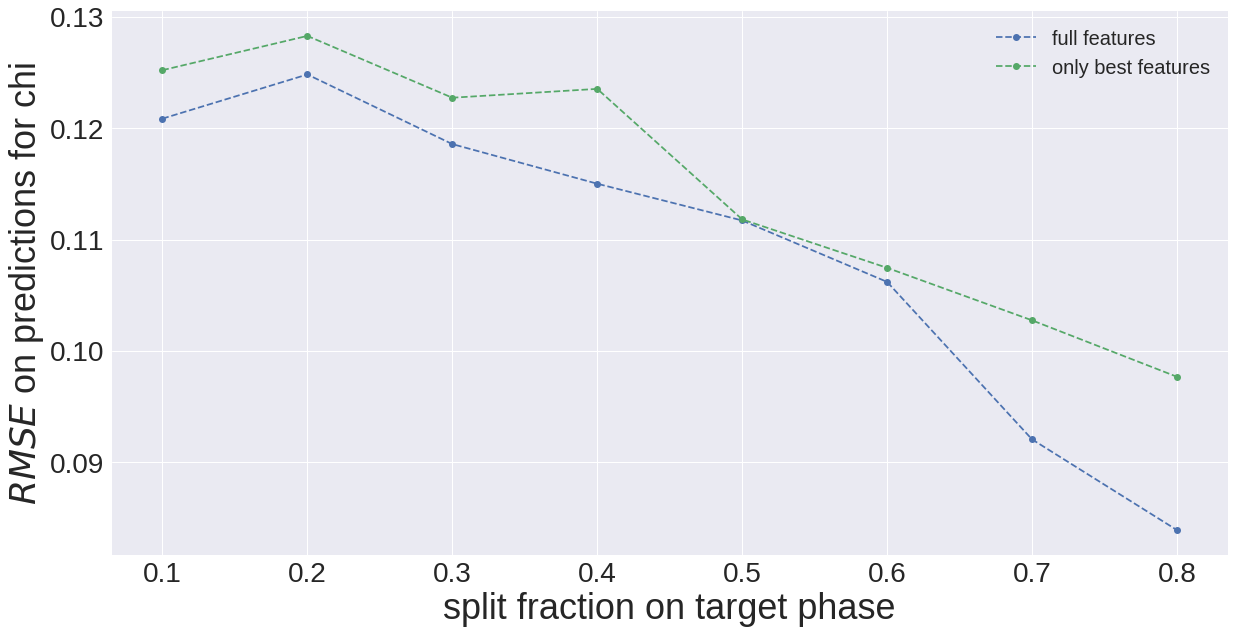

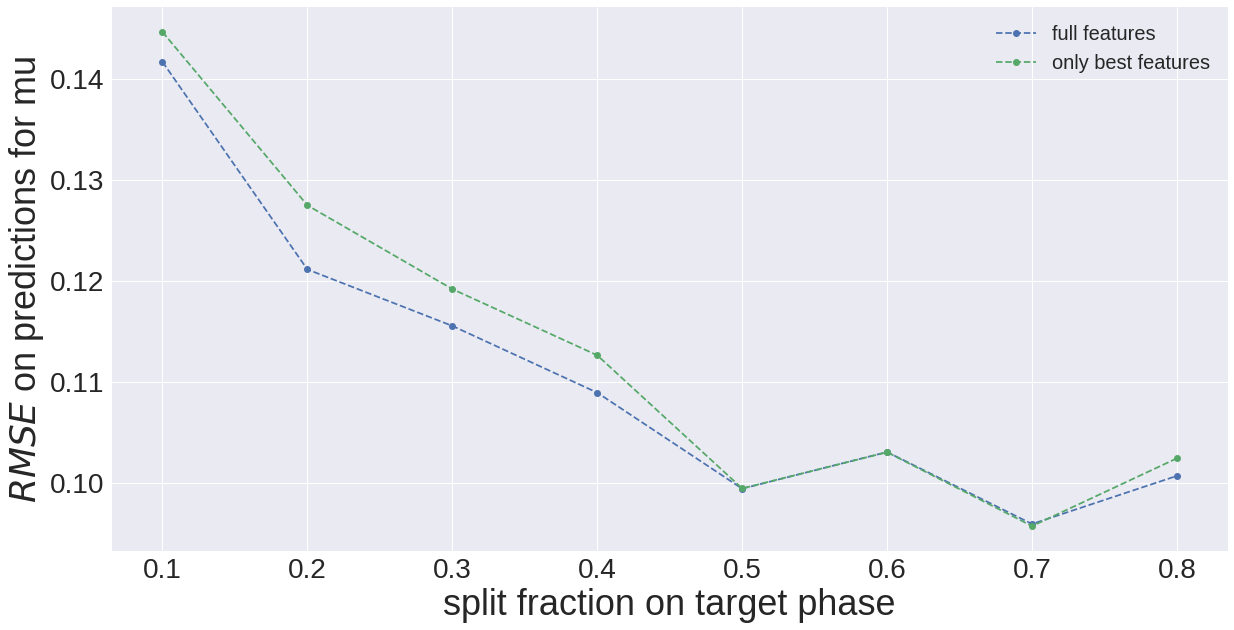

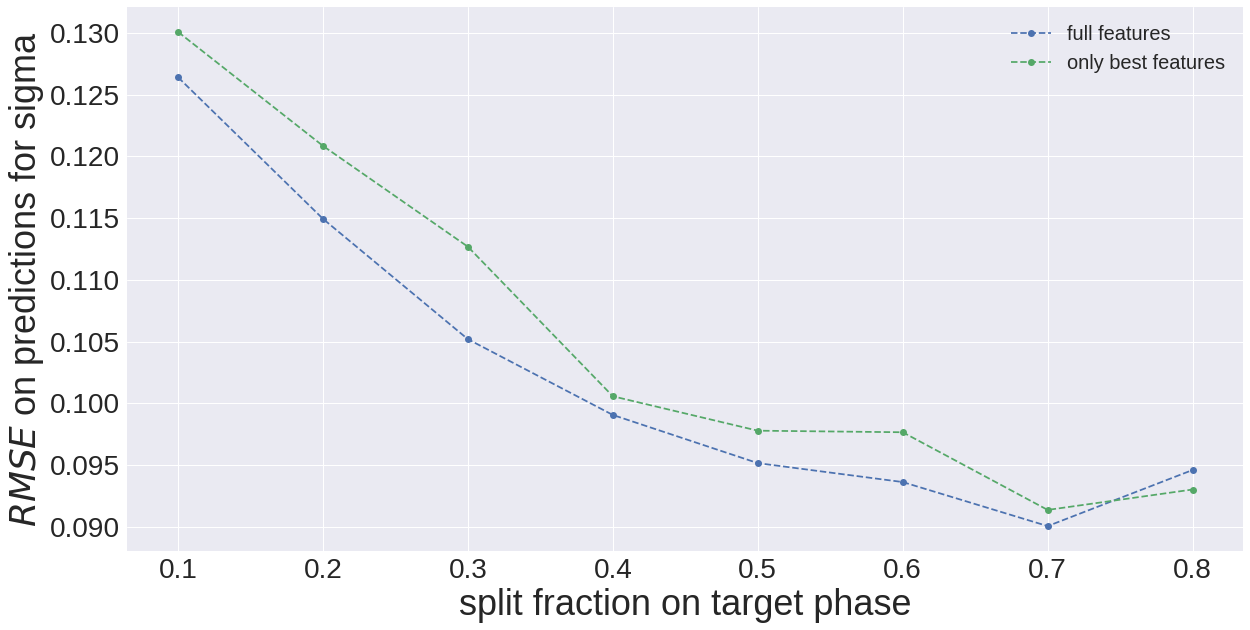

In [63]:
for p, phase in enumerate(Interesting_classes):
    if phase not in performances:
        splits, scoresbest, scorefull = incsplit(
            features_with_importances_weights[
                features_with_importances_weights['importancies']>0.02
            ]['features'],
            features_with_importances_weights['features'],
            phase=phase
        )
        performances[phase] = {'splits': splits, 'scoresbest': scoresbest, 'scoresfull':scorefull }
    else:
        fig, ax = plt.subplots()
        ax.plot(performances[phase]['splits'], performances[phase]['scoresfull'], '--o', label = 'full features')
        ax.plot(performances[phase]['splits'], performances[phase]['scoresbest'], '--o', label = 'only best features')
        ax.set_ylabel('$RMSE$ on predictions for {:s}'.format(phase))
        ax.set_xlabel('split fraction on target phase')
        fig.show()
#        ax.set_yticklabels(ax.get_yticklabels(), fontsize=3)
#        ax.set_xticklabels(ax.get_xticklabels(), fontsize=36)
        ax.legend()
        fig.savefig(f'graphs/incsplits_{phase}.pdf')

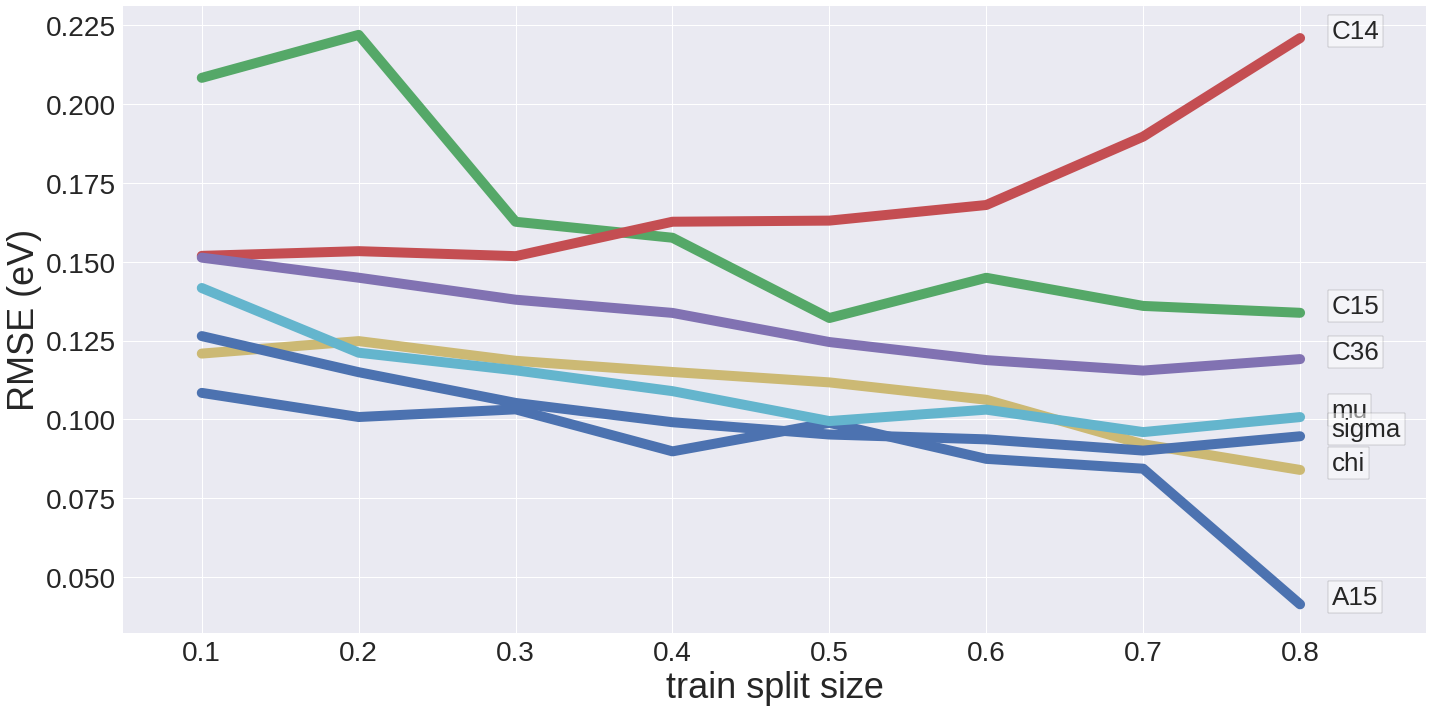

In [91]:
for phase in performances.keys():
    plt.plot(performances[phase]['splits'], performances[phase]['scoresfull'], linewidth=10)
    t = plt.text(performances[phase]['splits'][-1]+0.02, performances[phase]['scoresfull'][-1], phase, fontsize=26,)
    t.set_bbox(dict(facecolor='white', alpha=0.5))
plt.ylabel('RMSE (eV)')
plt.xlabel('train split size')
plt.xlim([0.05,0.88])
plt.gcf().tight_layout()
plt.savefig('graph/incsplits_by_phase.pdf')


In [62]:
performances_bondspecific = performances
%store performances_bondspecific

Stored 'performances_bondspecific' (dict)


In [73]:
performances['A15']['scoresfull'][-1]

0.04126012470875069